In [3]:
#import packages 

import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import numpy as np
from scipy.stats import linregress


In [4]:
#reading files 
# all pteropods

pterodata = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name= 'Summary') 

#drop Nans
#pterodata = pterodata.dropna()

waterpterodata = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name= 'Water Column Batch Analysis') 

wdata = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name = 'water column excluding nans')

pterodatacsv = "Pteropod_summary_MeCa.csv"
pterodata.to_csv(pterodatacsv, index=False)
pterodatacsv = pd.read_csv(pterodatacsv)


In [5]:
#index data by cleaning type or water column 

noclean = pterodatacsv[pterodatacsv['Cleaning'].str.contains('no clean')]
sonic = pterodatacsv[pterodatacsv['Cleaning'].str.contains('sonic only')]
redsonic = pterodatacsv[pterodatacsv['Cleaning'].str.contains('sonic+red', regex=False)]
oxredsonic = pterodatacsv[pterodatacsv['Cleaning'].str.contains('sonic++red+ox', regex=False)]
waterptero = pterodatacsv[pterodatacsv['Cleaning'].str.contains('na')]


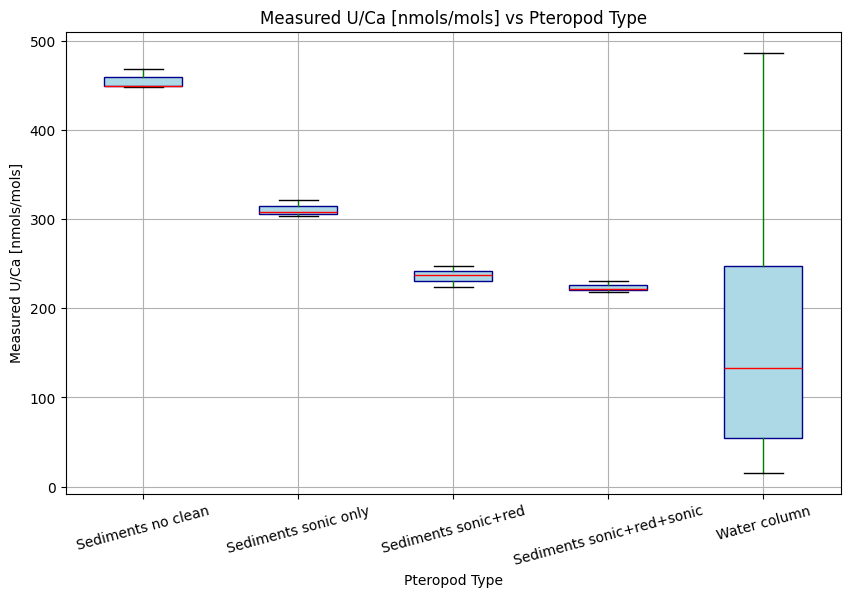

In [6]:
#Graph 1: U/Ca vs water column and sedimentary pteropods

# getting U nmols/ Ca mols from each cleaning type 
nocleanU = noclean['U/Ca [nmol/mol]']
sonicU = sonic['U/Ca [nmol/mol]']
redsonicU = redsonic['U/Ca [nmol/mol]']
oxredsonicU = oxredsonic['U/Ca [nmol/mol]']
waterpteroU = waterptero['U/Ca [nmol/mol]']


#combining data
cleantypeU = [nocleanU, sonicU, redsonicU, oxredsonicU, waterpteroU]
cleaningU = {
    'Sediments no clean' : nocleanU,
    'Sediments sonic only': sonicU,
    'Sediments sonic+red' : redsonicU,
    'Sediments sonic+red+sonic' : oxredsonicU,
    'Water column' : waterpteroU}

#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeU, tick_labels=cleaningU, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured U/Ca [nmols/mols]')

#plot title
plt.title('Measured U/Ca [nmols/mols] vs Pteropod Type')

#add grid lines
plt.grid()

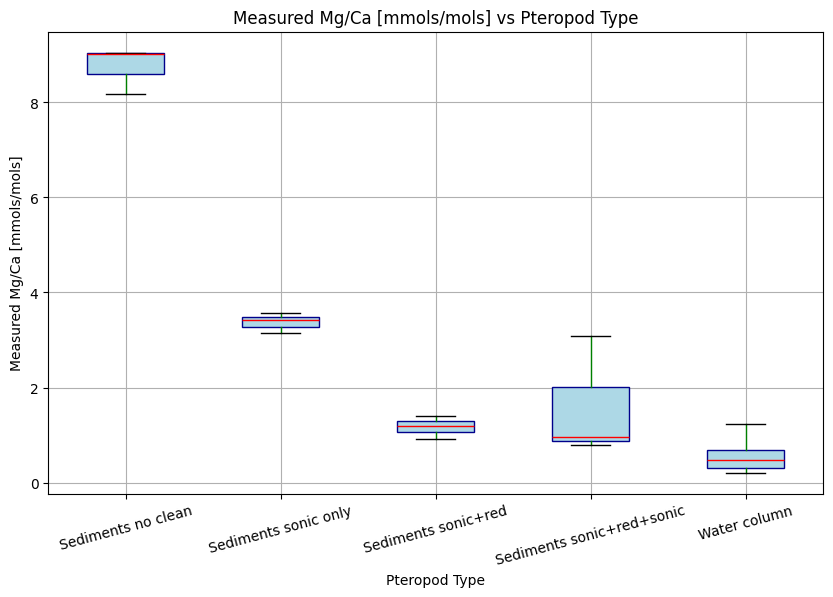

In [7]:
#Graph 2: Mg/Ca vs water column and sedimentary pteropods

# getting Mg mmols/ Ca mols from each cleaning type 
nocleanMg = noclean['Mg_Ca [mmol/mol]']
sonicMg = sonic['Mg_Ca [mmol/mol]']
redsonicMg = redsonic['Mg_Ca [mmol/mol]']
oxredsonicMg = oxredsonic['Mg_Ca [mmol/mol]']
waterpteroMg = waterptero['Mg_Ca [mmol/mol]'].dropna().values.flatten()

#combining data
cleantypeMg = nocleanMg, sonicMg, redsonicMg, oxredsonicMg, waterpteroMg
cleaningMg = {
     'Sediments no clean' : nocleanMg,
    'Sediments sonic only': sonicMg,
    'Sediments sonic+red' : redsonicMg,
    'Sediments sonic+red+sonic' : oxredsonicMg,
    'Water column' : waterpteroMg}


#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeMg, tick_labels=cleaningMg, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured Mg/Ca [mmols/mols]')

#plot title
plt.title('Measured Mg/Ca [mmols/mols] vs Pteropod Type')

#add grid lines
plt.grid()



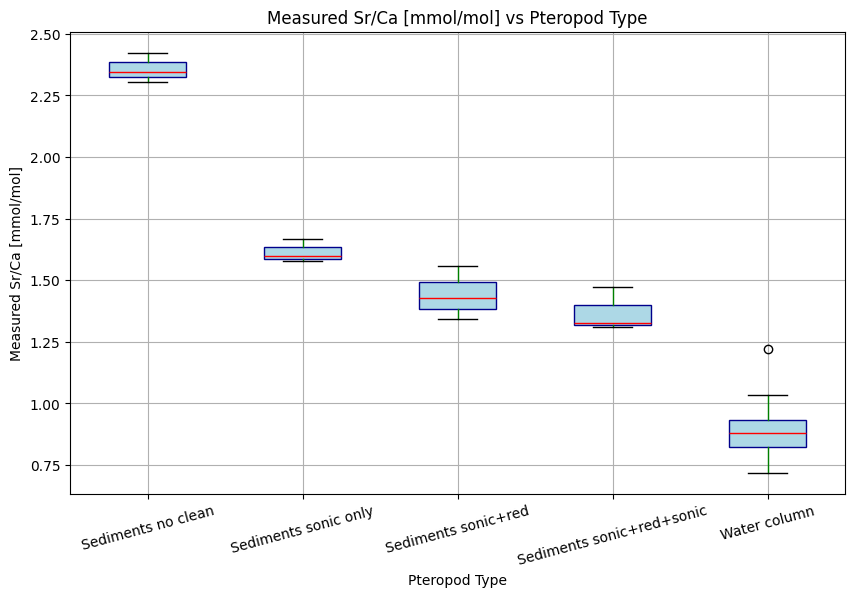

In [8]:
#Graph 3: Sr/Ca vs water column and sedimentary pteropods

# getting Sr mmols/ Ca mols from each cleaning type 
nocleanSr = noclean['Sr/Ca [mmol/mol]']
sonicSr = sonic['Sr/Ca [mmol/mol]']
redsonicSr = redsonic['Sr/Ca [mmol/mol]']
oxredsonicSr = oxredsonic['Sr/Ca [mmol/mol]']
waterpteroSr = waterptero['Sr/Ca [mmol/mol]'].dropna().values.flatten()

#combining data
cleantypeSr = nocleanSr, sonicSr, redsonicSr, oxredsonicSr, waterpteroSr
cleaningSr = {
    'Sediments no clean' : nocleanSr,
    'Sediments sonic only': sonicSr,
    'Sediments sonic+red' : redsonicSr,
    'Sediments sonic+red+sonic' : oxredsonicSr,
    'Water column' : waterpteroSr}


#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeSr, tick_labels=cleaningSr, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured Sr/Ca [mmol/mol]')

#plot title
plt.title('Measured Sr/Ca [mmol/mol] vs Pteropod Type')

#add grid lines
plt.grid()



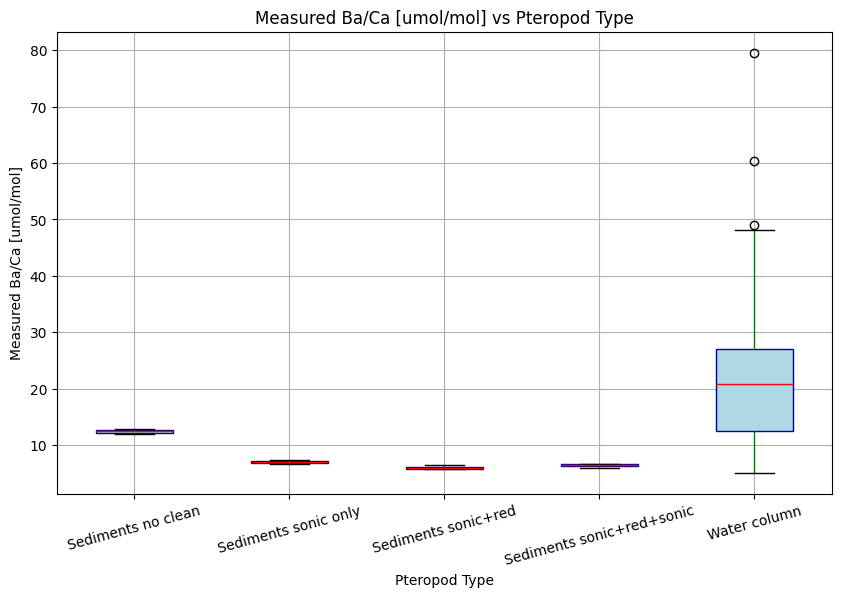

In [9]:
#Graph 4: Ba/Ca vs water column and sedimentary pteropods

# getting Ba umols/ Ca mols from each cleaning type 
nocleanBa = noclean['Ba/Ca [umol/mol]']
sonicBa = sonic['Ba/Ca [umol/mol]']
redsonicBa = redsonic['Ba/Ca [umol/mol]']
oxredsonicBa = oxredsonic['Ba/Ca [umol/mol]']
waterpteroBa = waterptero['Ba/Ca [umol/mol]']

#combining data
cleantypeBa = nocleanBa, sonicBa, redsonicBa, oxredsonicBa, waterpteroBa
cleaningBa = {
    'Sediments no clean' : nocleanBa,
    'Sediments sonic only': sonicBa,
    'Sediments sonic+red' : redsonicBa,
    'Sediments sonic+red+sonic' : oxredsonicBa,
    'Water column' : waterpteroBa}


#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeBa, tick_labels=cleaningBa, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured Ba/Ca [umol/mol]')

#plot title
plt.title('Measured Ba/Ca [umol/mol] vs Pteropod Type')

#add grid lines
plt.grid()



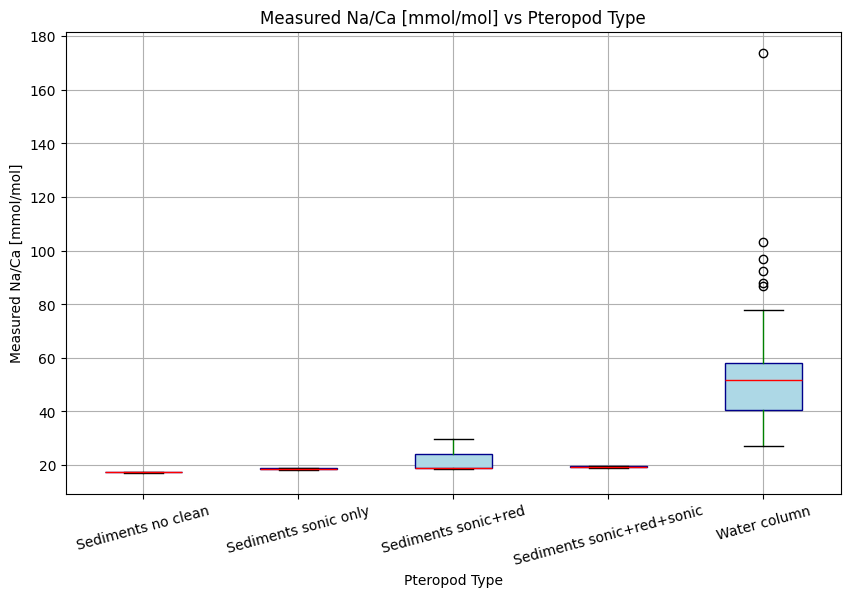

In [10]:
#Graph 5: Na/Ca vs water column and sedimentary pteropods

# getting Na mmols/ Ca mols from each cleaning type 
nocleanNa = noclean['Na_Ca [mmol/mol]']
sonicNa = sonic['Na_Ca [mmol/mol]']
redsonicNa = redsonic['Na_Ca [mmol/mol]']
oxredsonicNa = oxredsonic['Na_Ca [mmol/mol]']
waterpteroNa = waterptero['Na_Ca [mmol/mol]'].dropna().values.flatten()

#combining data
cleantypeNa = nocleanNa, sonicNa, redsonicNa, oxredsonicNa, waterpteroNa
cleaningNa = {
    'Sediments no clean' : nocleanNa,
    'Sediments sonic only': sonicNa,
    'Sediments sonic+red' : redsonicNa,
    'Sediments sonic+red+sonic' : oxredsonicNa,
    'Water column' : waterpteroNa}


#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeNa, tick_labels=cleaningNa, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured Na/Ca [mmol/mol]')

#plot title
plt.title('Measured Na/Ca [mmol/mol] vs Pteropod Type')

#add grid lines
plt.grid()



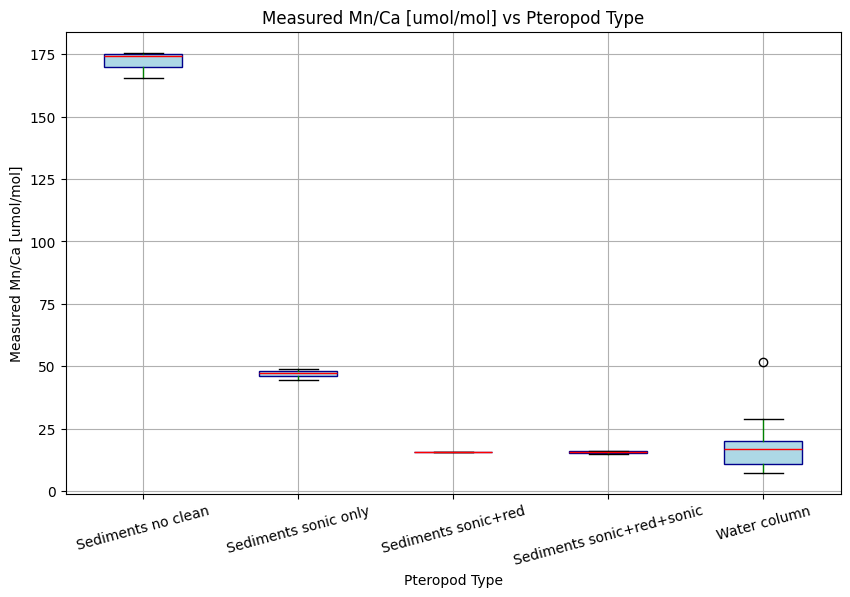

In [11]:
#Graph 6: Mn/Ca vs water column and sedimentary pteropods

# getting Mn umols/ Ca mols from each cleaning type 
nocleanMn = noclean['Mn_Ca [umol/mol]']
sonicMn = sonic['Mn_Ca [umol/mol]']
redsonicMn = redsonic['Mn_Ca [umol/mol]']
oxredsonicMn = oxredsonic['Mn_Ca [umol/mol]']
waterpteroMn = waterptero['Mn_Ca [umol/mol]'].dropna().values.flatten()

#combining data
cleantypeMn = nocleanMn, sonicMn, redsonicMn, oxredsonicMn, waterpteroMn
cleaningMn = {
    'Sediments no clean' : nocleanMn,
    'Sediments sonic only': sonicMn,
    'Sediments sonic+red' : redsonicMn,
    'Sediments sonic+red+sonic' : oxredsonicMn,
    'Water column' : waterpteroMn}


#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeMn, tick_labels=cleaningMn, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured Mn/Ca [umol/mol]')

#plot title
plt.title('Measured Mn/Ca [umol/mol] vs Pteropod Type')

#add grid lines
plt.grid()



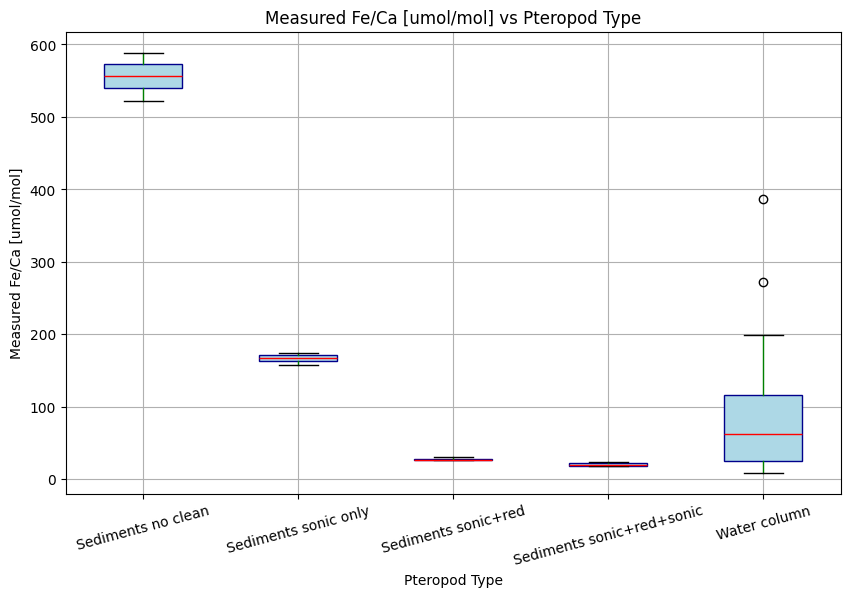

In [12]:
#Graph 7: Fe/Ca vs water column and sedimentary pteropods

# getting Fe umols/ Ca mols from each cleaning type 
nocleanFe = noclean['Fe_Ca [umol/mol]']
sonicFe = sonic['Fe_Ca [umol/mol]']
redsonicFe = redsonic['Fe_Ca [umol/mol]']
oxredsonicFe = oxredsonic['Fe_Ca [umol/mol]']
waterpteroFe = waterptero['Fe_Ca [umol/mol]'].dropna().values.flatten()

#combining data
cleantypeFe = nocleanFe, sonicFe, redsonicFe, oxredsonicFe, waterpteroFe
cleaningFe = {
    'Sediments no clean' : nocleanFe,
    'Sediments sonic only': sonicFe,
    'Sediments sonic+red' : redsonicFe,
    'Sediments sonic+red+sonic' : oxredsonicFe,
    'Water column' : waterpteroFe}


#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeFe, tick_labels=cleaningFe, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured Fe/Ca [umol/mol]')

#plot title
plt.title('Measured Fe/Ca [umol/mol] vs Pteropod Type')

#add grid lines
plt.grid()



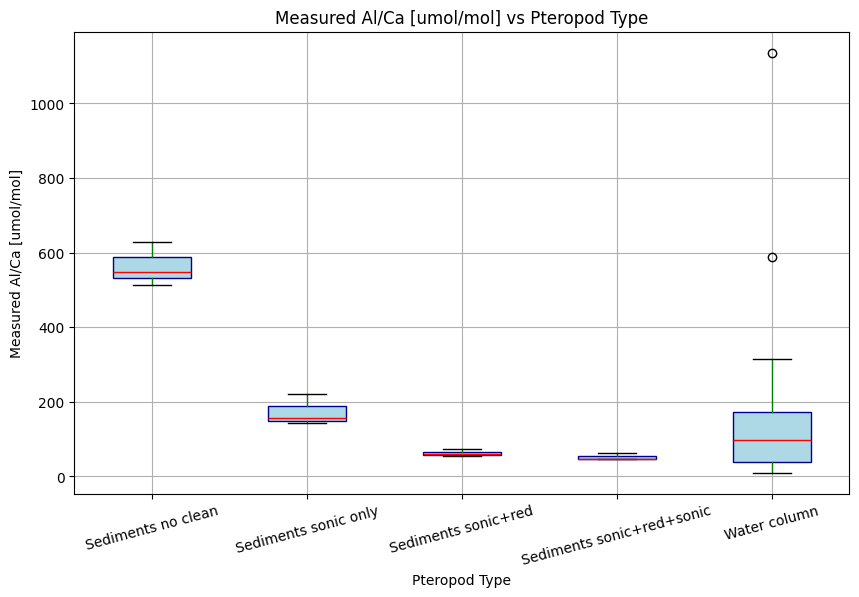

In [13]:
#Graph 8: Al/Ca vs water column and sedimentary pteropods

# getting Fe umols/ Ca mols from each cleaning type 
nocleanAl = noclean['Al_Ca [umol/mol]']
sonicAl = sonic['Al_Ca [umol/mol]']
redsonicAl = redsonic['Al_Ca [umol/mol]']
oxredsonicAl = oxredsonic['Al_Ca [umol/mol]']
waterpteroAl = waterptero['Al_Ca [umol/mol]'].dropna().values.flatten()

#combining data
cleantypeAl = nocleanAl, sonicAl, redsonicAl, oxredsonicAl, waterpteroAl
cleaningAl = {
    'Sediments no clean' : nocleanAl,
    'Sediments sonic only': sonicAl,
    'Sediments sonic+red' : redsonicAl,
    'Sediments sonic+red+sonic' : oxredsonicAl,
    'Water column' : waterpteroAl}


#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(cleantypeAl, tick_labels=cleaningAl, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))

# put x axis labels at slight angle
plt.xticks(rotation=15)

#label axes
plt.xlabel('Pteropod Type')
plt.ylabel('Measured Al/Ca [umol/mol]')

#plot title
plt.title('Measured Al/Ca [umol/mol] vs Pteropod Type')

#add grid lines
plt.grid()



In [14]:
#labels for boxplots 

labelSr= {
    '1' : nocleanSr,
    '2': sonicSr,
    '3' : redsonicSr,
    '4' : oxredsonicSr,
    '5' : waterpteroSr }
labelBa= {
    '1' : nocleanBa,
    '2': sonicBa,
    '3' : redsonicBa,
    '4' : oxredsonicBa,
    '5' : waterpteroBa}
labelU= {
    '1' : nocleanU,
    '2': sonicU,
    '3' : redsonicU,
    '4' : oxredsonicU,
    '5' : waterpteroU }
labelNa= {
    '1' : nocleanNa,
    '2': sonicNa,
    '3' : redsonicNa,
    '4' : oxredsonicNa,
    '5' : waterpteroNa }
labelMg= {
    '1' : nocleanMg,
    '2': sonicMg,
    '3' : redsonicMg,
    '4' : oxredsonicMg,
    '5' : waterpteroMg }
labelMn= {
    '1' : nocleanMn,
    '2': sonicMn,
    '3' : redsonicMn,
    '4' : oxredsonicMn,
    '5' : waterpteroMn }
labelFe= {
    '1' : nocleanFe,
    '2': sonicFe,
    '3' : redsonicFe,
    '4' : oxredsonicFe,
    '5' : waterpteroFe}
labelAl= {
    '1' : nocleanAl,
    '2': sonicAl,
    '3' : redsonicAl,
    '4' : oxredsonicAl,
    '5' : waterpteroAl }

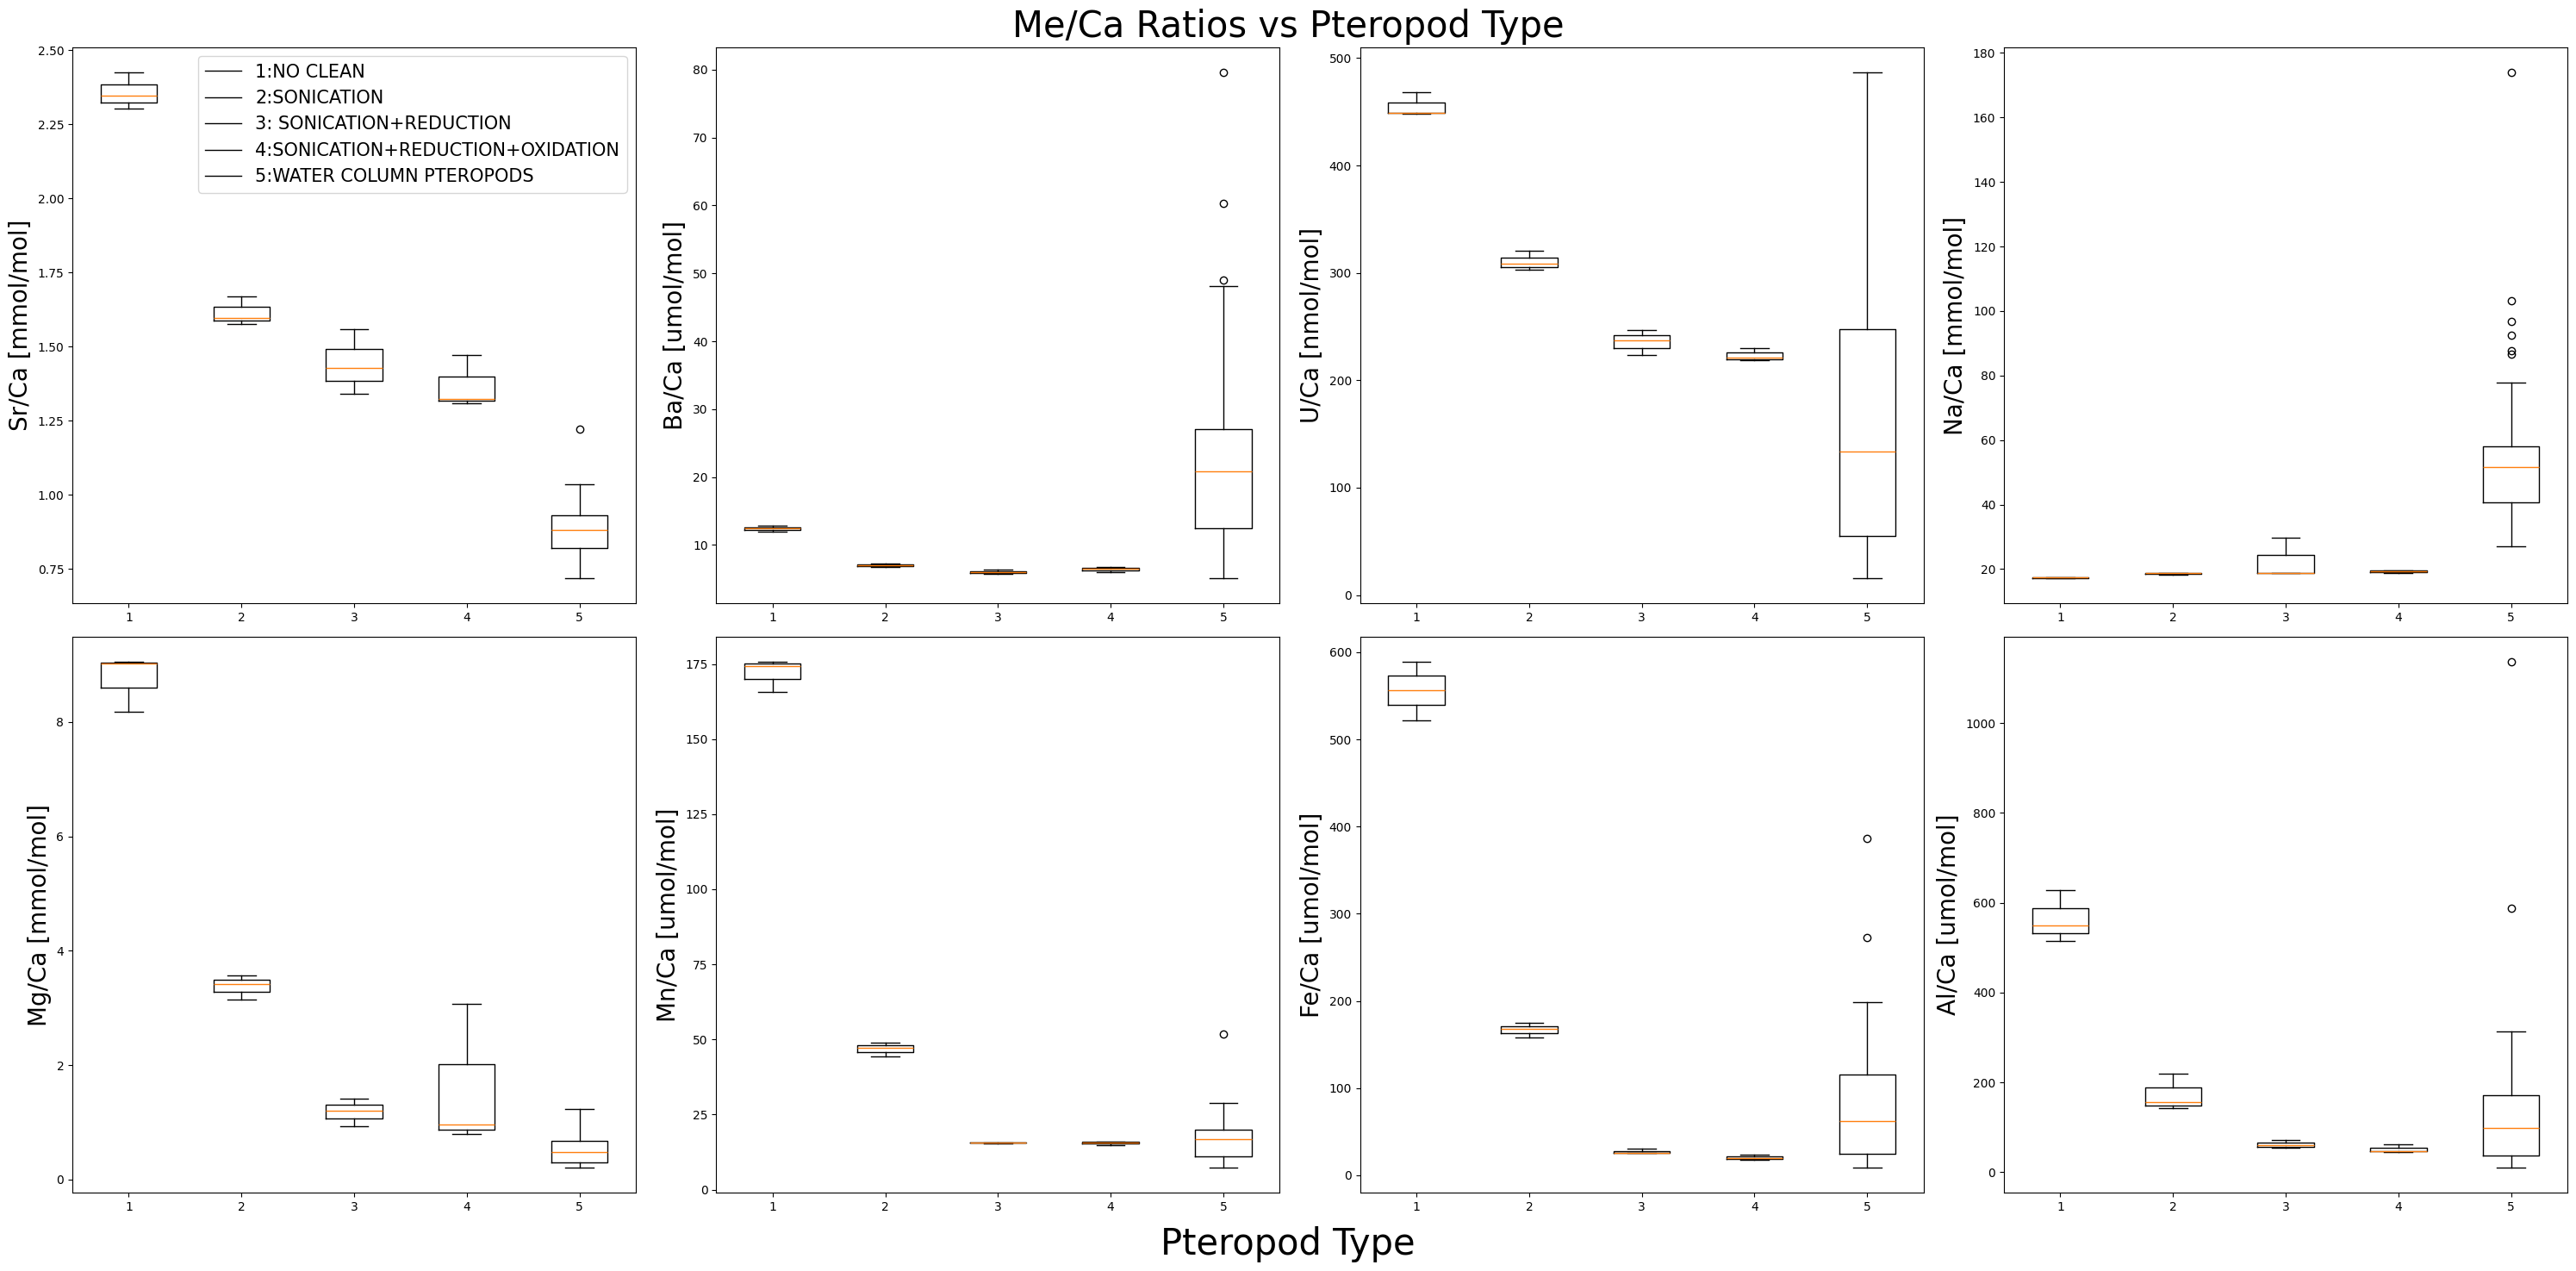

In [15]:
#Graph 9: combined Me/Ca ratios vs different cleaning types sedimentary pterods and water column pteropods 



#create figure
fig, axes = plt.subplots(2, 4, figsize=(30, 15), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()


#create boxplots

# add this code to make boxplots colorful
# , patch_artist=True,
#             boxprops=dict(facecolor='lightblue', color='darkblue'),
#             medianprops=dict(color='red'),
#             whiskerprops=dict(color='green'))

ax1.boxplot(cleantypeSr, tick_labels=labelSr)

ax2.boxplot(cleantypeBa, tick_labels=labelBa)

ax3.boxplot(cleantypeU, tick_labels=labelU)

ax4.boxplot(cleantypeNa, tick_labels=labelNa)

ax5.boxplot(cleantypeMg, tick_labels=labelMg)

ax6.boxplot(cleantypeMn, tick_labels=labelMn)

ax7.boxplot(cleantypeFe, tick_labels=labelFe) 

ax8.boxplot(cleantypeAl, tick_labels=labelAl)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios vs Pteropod Type', fontsize = 30)
fig.supxlabel('Pteropod Type', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)
lab = '1:NO CLEAN', '2:SONICATION', '3: SONICATION+REDUCTION', '4:SONICATION+REDUCTION+OXIDATION', '5:WATER COLUMN PTEROPODS'
#set legend
ax1.legend(lab, fontsize = 15)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



In [65]:
# nocleanMn = noclean['Mn_Ca [umol/mol]']
# sonicMn = sonic['Mn_Ca [umol/mol]']
# redsonicMn = redsonic['Mn_Ca [umol/mol]']
# oxredsonicMn = oxredsonic['Mn_Ca [umol/mol]']
waterpteroMn = waterptero['Mn_Ca [umol/mol]'].dropna().values.flatten()

#remove outliers:
wAl = waterpteroAl[0:31]
wFe = waterpteroFe[0:31]

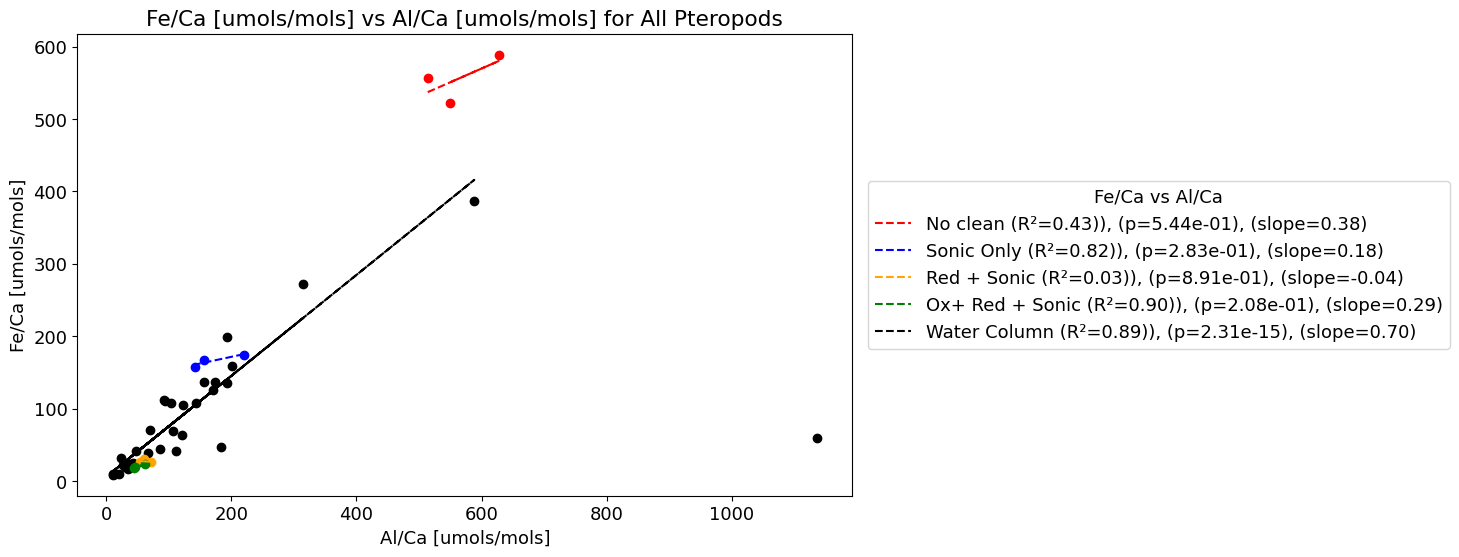

In [73]:
#graph 10 Fe/Ca vs Al/Ca linear regression for sedimentary pteropods

# calulate linear regression
#no clean
slopeFeAl, interceptFeAl, r_valueFeAl, p_valueFeAl, std_errFeAl = linregress(nocleanAl, nocleanFe)
regression_yFeAl = slopeFeAl * nocleanAl + interceptFeAl
r_squaredFeAl = r_valueFeAl**2

#sonic only
slopesonicFeAl, interceptsonicFeAl, r_valuesonicFeAl, p_valuesonicFeAl, std_errsonicFeAl = linregress(sonicAl, sonicFe)
regression_ysonicFeAl = slopesonicFeAl * sonicAl + interceptsonicFeAl
r_squaredsonicFeAl = r_valuesonicFeAl**2

#sonic+red
sloperedFeAl, interceptredFeAl, r_valueredFeAl, p_valueredFeAl, std_errredFeAl = linregress(redsonicAl, redsonicFe)
regression_yredFeAl = sloperedFeAl * redsonicAl + interceptredFeAl
r_squaredredFeAl = r_valueredFeAl**2

#sonic+red+ox
sloperedoxFeAl, interceptredoxFeAl, r_valueredoxFeAl, p_valueredoxFeAl, std_errredoxFeAl = linregress(oxredsonicAl, oxredsonicFe)
regression_yredoxFeAl = sloperedoxFeAl * oxredsonicAl + interceptredoxFeAl
r_squaredredoxFeAl = r_valueredoxFeAl**2

#water column 
slopewaterFeAl, interceptwaterFeAl, r_valuewaterFeAl, p_valuewaterFeAl, std_errwaterFeAl = linregress(wAl, wFe)
regression_ywaterFeAl = slopewaterFeAl * wAl + interceptwaterFeAl
r_squaredwaterFeAl = r_valuewaterFeAl**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(waterpteroAl, waterpteroFe, color = 'black')
plt.scatter(nocleanAl, nocleanFe, color = 'r')
plt.scatter(sonicAl, sonicFe, color = 'b')
plt.scatter(redsonicAl, redsonicFe, color = 'orange')
plt.scatter(oxredsonicAl, oxredsonicFe, color = 'green')


#plot linear regression
#noclean
plt.plot(nocleanAl, regression_yFeAl, label=f'No clean (R²={r_squaredFeAl:.2f})), (p={p_valueFeAl:.2e}), (slope={slopeFeAl:.2f})', color='r', linestyle='--')
#sonic only
plt.plot(sonicAl, regression_ysonicFeAl, label=f'Sonic Only (R²={r_squaredsonicFeAl:.2f})), (p={p_valuesonicFeAl:.2e}), (slope={slopesonicFeAl:.2f})', color='b', linestyle='--')
#red+sonic
plt.plot(redsonicAl, regression_yredFeAl, label=f'Red + Sonic (R²={r_squaredredFeAl:.2f})), (p={p_valueredFeAl:.2e}), (slope={sloperedFeAl:.2f})', color='orange', linestyle='--')
#ox+red+sonic
plt.plot(oxredsonicAl, regression_yredoxFeAl, label=f'Ox+ Red + Sonic (R²={r_squaredredoxFeAl:.2f})), (p={p_valueredoxFeAl:.2e}), (slope={sloperedoxFeAl:.2f})', color='green', linestyle='--')
#water column
plt.plot(wAl, regression_ywaterFeAl, label=f'Water Column (R²={r_squaredwaterFeAl:.2f})), (p={p_valuewaterFeAl:.2e}), (slope={slopewaterFeAl:.2f})', color='black', linestyle='--')

# axis labels 
plt.ylabel('Fe/Ca [umols/mols]')
plt.xlabel('Al/Ca [umols/mols]')

#plot title
plt.title('Fe/Ca [umols/mols] vs Al/Ca [umols/mols] for All Pteropods')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='Fe/Ca vs Al/Ca', borderaxespad=0)




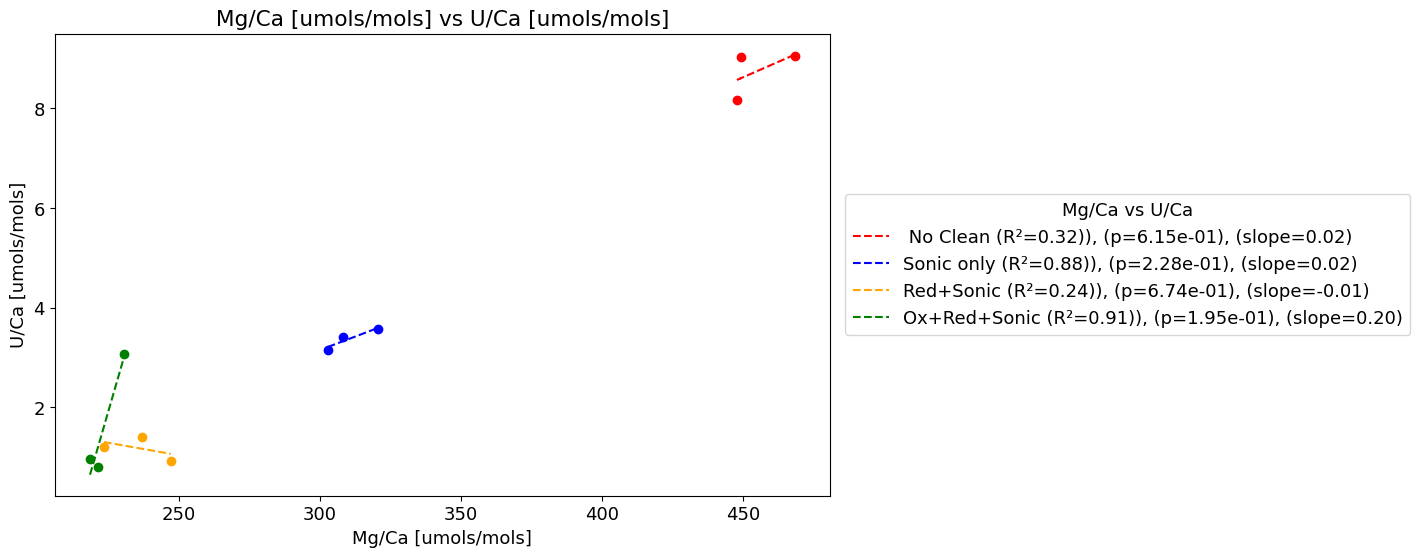

In [18]:
#graph 11 U/Ca vs Mg/Ca linear regression for sedimentary pteropods
 
# calulate linear regression
#no clean
slopeUMg, interceptUMg, r_valueUMg, p_valueUMg, std_errUMg = linregress(nocleanU, nocleanMg)
regression_yUMg = slopeUMg * nocleanU + interceptUMg
r_squaredUMg = r_valueUMg**2

#sonic only
slopesonicUMg, interceptsonicUMg, r_valuesonicUMg, p_valuesonicUMg, std_errsonicUMg = linregress(sonicU, sonicMg)
regression_ysonicUMg = slopesonicUMg * sonicU + interceptsonicUMg
r_squaredsonicUMg = r_valuesonicUMg**2

#sonic+red
sloperedUMg, interceptredUMg, r_valueredUMg, p_valueredUMg, std_errredUMg = linregress(redsonicU, redsonicMg)
regression_yredUMg = sloperedUMg * redsonicU + interceptredUMg
r_squaredredUMg = r_valueredUMg**2

#sonic+red+ox
sloperedoxUMg, interceptredoxUMg, r_valueredoxUMg, p_valueredoxUMg, std_errredoxUMg = linregress(oxredsonicU, oxredsonicMg)
regression_yredoxUMg = sloperedoxUMg * oxredsonicU + interceptredoxUMg
r_squaredredoxUMg = r_valueredoxUMg**2

# #water column pteropods
# slopeWUMg, interceptWUMg, r_valueWUMg, p_valueWUMg, std_errWUMg = linregress(waterpteroU, waterpteroMg)
# regression_yWUMg = slopeWUMg * waterpteroU + interceptWUMg
# r_squaredWUMg = r_valueWUMg**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(nocleanU, nocleanMg,color = 'r')
plt.scatter(sonicU, sonicMg, color = 'b')
plt.scatter(redsonicU, redsonicMg, color = 'orange')
plt.scatter(oxredsonicU, oxredsonicMg, color = 'green')
# plt.scatter(waterpteroU, waterpteroMg, color = 'yellow')

#plot linear regression
#noclean
plt.plot(nocleanU, regression_yUMg, label=f' No Clean (R²={r_squaredUMg:.2f})), (p={p_valueUMg:.2e}), (slope={slopeUMg:.2f})', color='r', linestyle='--')
#sonic only
plt.plot(sonicU, regression_ysonicUMg, label=f'Sonic only (R²={r_squaredsonicUMg:.2f})), (p={p_valuesonicUMg:.2e}), (slope={slopesonicUMg:.2f})', color='b', linestyle='--')
#red+sonic
plt.plot(redsonicU, regression_yredUMg, label=f'Red+Sonic (R²={r_squaredredUMg:.2f})), (p={p_valueredUMg:.2e}), (slope={sloperedUMg:.2f})', color='orange', linestyle='--')
#ox+red+sonic
plt.plot(oxredsonicU, regression_yredoxUMg, label=f'Ox+Red+Sonic (R²={r_squaredredoxUMg:.2f})), (p={p_valueredoxUMg:.2e}), (slope={sloperedoxUMg:.2f})', color='green', linestyle='--')
# #water column 
# plt.plot(waterpteroU, regression_yWUMg, label=f'Sediment Trap Pteropods(R²={r_squaredWUMg:.2f})), (p={p_valueWUMg:.2e}), (slope={slopeWUMg:.2f})', color='yellow', linestyle='--')

# axis labels 
plt.ylabel('U/Ca [umols/mols]')
plt.xlabel('Mg/Ca [umols/mols]')

#plot title
plt.title(' Mg/Ca [umols/mols] vs U/Ca [umols/mols] ')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='Mg/Ca vs U/Ca', borderaxespad=0)



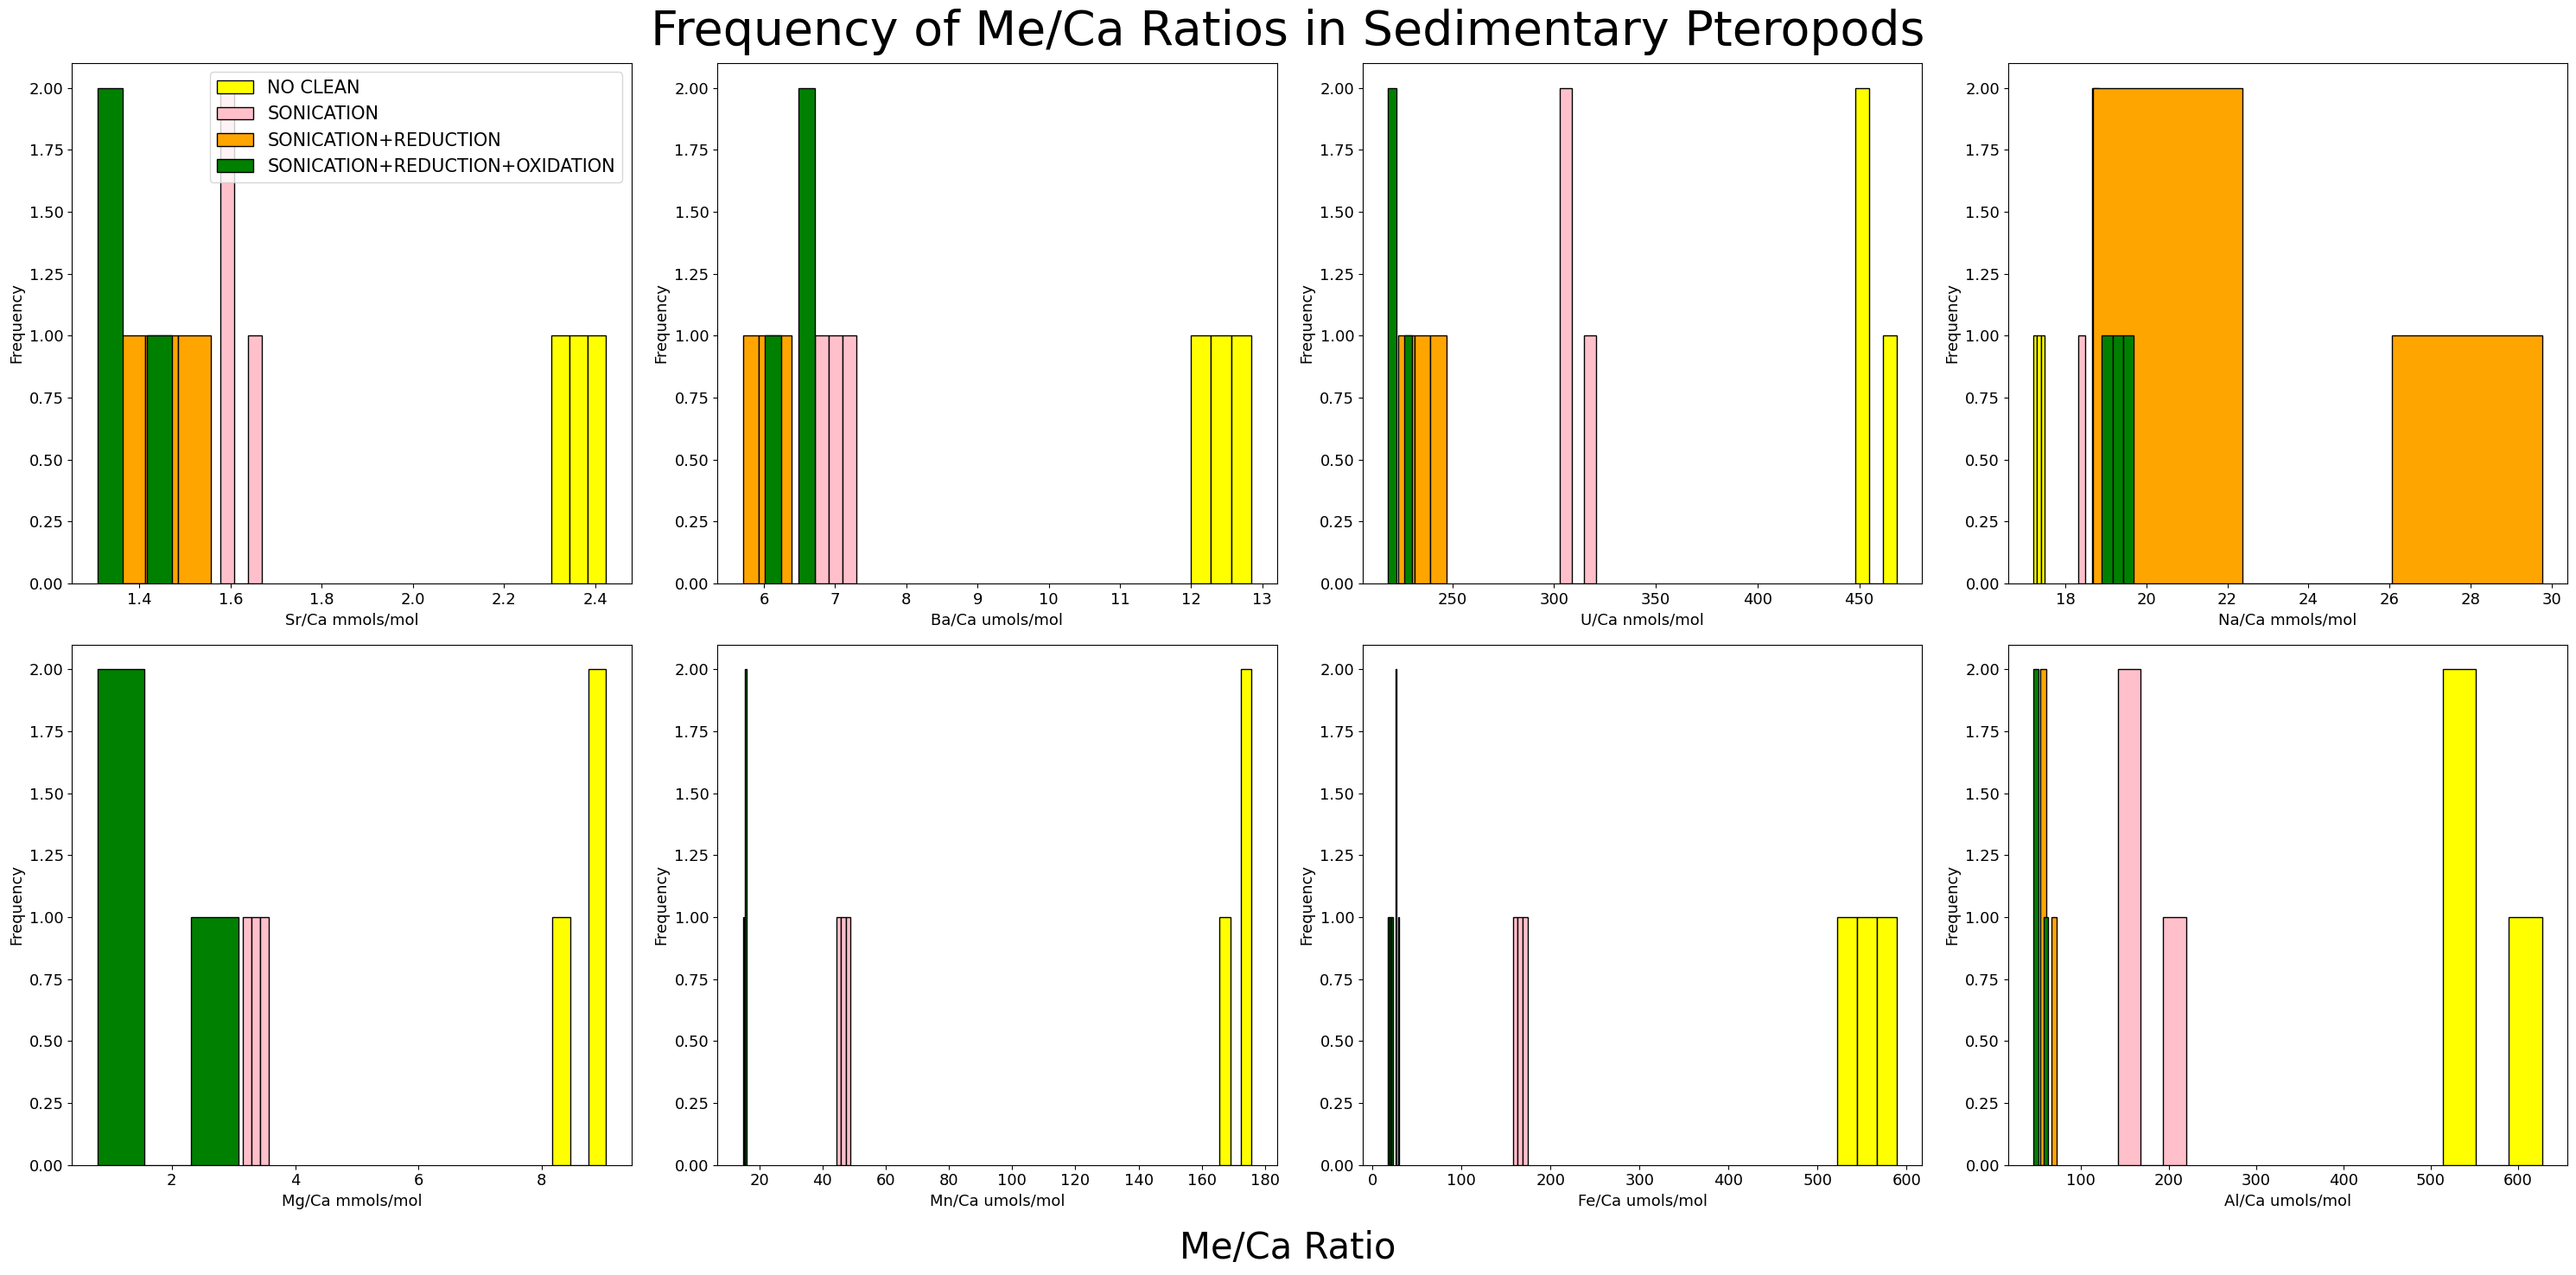

In [19]:
# graph 12: Creating subplots with multiple histograms for Me/Ca for sedimentary pteropods
fig, (axes) = plt.subplots(nrows=2, ncols=4, figsize=(30, 15))

#Sr/Ca
axes[0,0].hist(nocleanSr, bins=3, color='Yellow', edgecolor='black')

axes[0,0].hist(sonicSr, bins=3, color='Pink', edgecolor='black')

axes[0,0].hist(redsonicSr, bins=3, color='orange', edgecolor='black')

axes[0,0].hist(oxredsonicSr, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[0,0].set_xlabel('Sr/Ca mmols/mol')
axes[0,0].set_ylabel('Frequency')

#Ba/Ca
axes[0,1].hist(nocleanBa, bins=3, color='Yellow', edgecolor='black')

axes[0,1].hist(sonicBa, bins=3, color='Pink', edgecolor='black')

axes[0,1].hist(redsonicBa, bins=3, color='orange', edgecolor='black')

axes[0,1].hist(oxredsonicBa, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[0,1].set_xlabel('Ba/Ca umols/mol')
axes[0,1].set_ylabel('Frequency')


#U/Ca
axes[0,2].hist(nocleanU, bins=3, color='Yellow', edgecolor='black')

axes[0,2].hist(sonicU, bins=3, color='Pink', edgecolor='black')

axes[0,2].hist(redsonicU, bins=3, color='orange', edgecolor='black')

axes[0,2].hist(oxredsonicU, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[0,2].set_xlabel('U/Ca nmols/mol')
axes[0,2].set_ylabel('Frequency')

#Na/Ca
axes[0,3].hist(nocleanNa, bins=3, color='Yellow', edgecolor='black')

axes[0,3].hist(sonicNa, bins=3, color='Pink', edgecolor='black')

axes[0,3].hist(redsonicNa, bins=3, color='orange', edgecolor='black')

axes[0,3].hist(oxredsonicNa, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[0,3].set_xlabel('Na/Ca mmols/mol')
axes[0,3].set_ylabel('Frequency')

#Mg/Ca

axes[1,0].hist(nocleanMg, bins=3, color='Yellow', edgecolor='black')

axes[1,0].hist(sonicMg, bins=3, color='Pink', edgecolor='black')

axes[1,0].hist(redsonicMg, bins=3, color='orange', edgecolor='black')

axes[1,0].hist(oxredsonicMg, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[1,0].set_xlabel('Mg/Ca mmols/mol')
axes[1,0].set_ylabel('Frequency')

#Mn/Ca

axes[1,1].hist(nocleanMn, bins=3, color='Yellow', edgecolor='black')

axes[1,1].hist(sonicMn, bins=3, color='Pink', edgecolor='black')

axes[1,1].hist(redsonicMn, bins=3, color='orange', edgecolor='black')

axes[1,1].hist(oxredsonicMn, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[1,1].set_xlabel('Mn/Ca umols/mol')
axes[1,1].set_ylabel('Frequency')

#Fe/Ca

axes[1,2].hist(nocleanFe, bins=3, color='Yellow', edgecolor='black')

axes[1,2].hist(sonicFe, bins=3, color='Pink', edgecolor='black')

axes[1,2].hist(redsonicFe, bins=3, color='orange', edgecolor='black')

axes[1,2].hist(oxredsonicFe, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[1,2].set_xlabel('Fe/Ca umols/mol')
axes[1,2].set_ylabel('Frequency')

#Al/Ca

axes[1,3].hist(nocleanAl, bins=3, color='Yellow', edgecolor='black')

axes[1,3].hist(sonicAl, bins=3, color='Pink', edgecolor='black')

axes[1,3].hist(redsonicAl, bins=3, color='orange', edgecolor='black')

axes[1,3].hist(oxredsonicAl, bins=3, color='green', edgecolor='black')

# Adding labels and title
axes[1,3].set_xlabel('Al/Ca umols/mol')
axes[1,3].set_ylabel('Frequency')

fig.suptitle('Frequency of Me/Ca Ratios in Sedimentary Pteropods', fontsize = 40)
fig.supxlabel('Me/Ca Ratio', fontsize = 30)


# Adjusting layout for better spacing
fig.tight_layout()

#legend
tech = 'NO CLEAN', 'SONICATION', 'SONICATION+REDUCTION', 'SONICATION+REDUCTION+OXIDATION', 'WATER COLUMN PTEROPODS'
axes[0,0].legend(tech, fontsize = 15)

# Display the figure
plt.show()

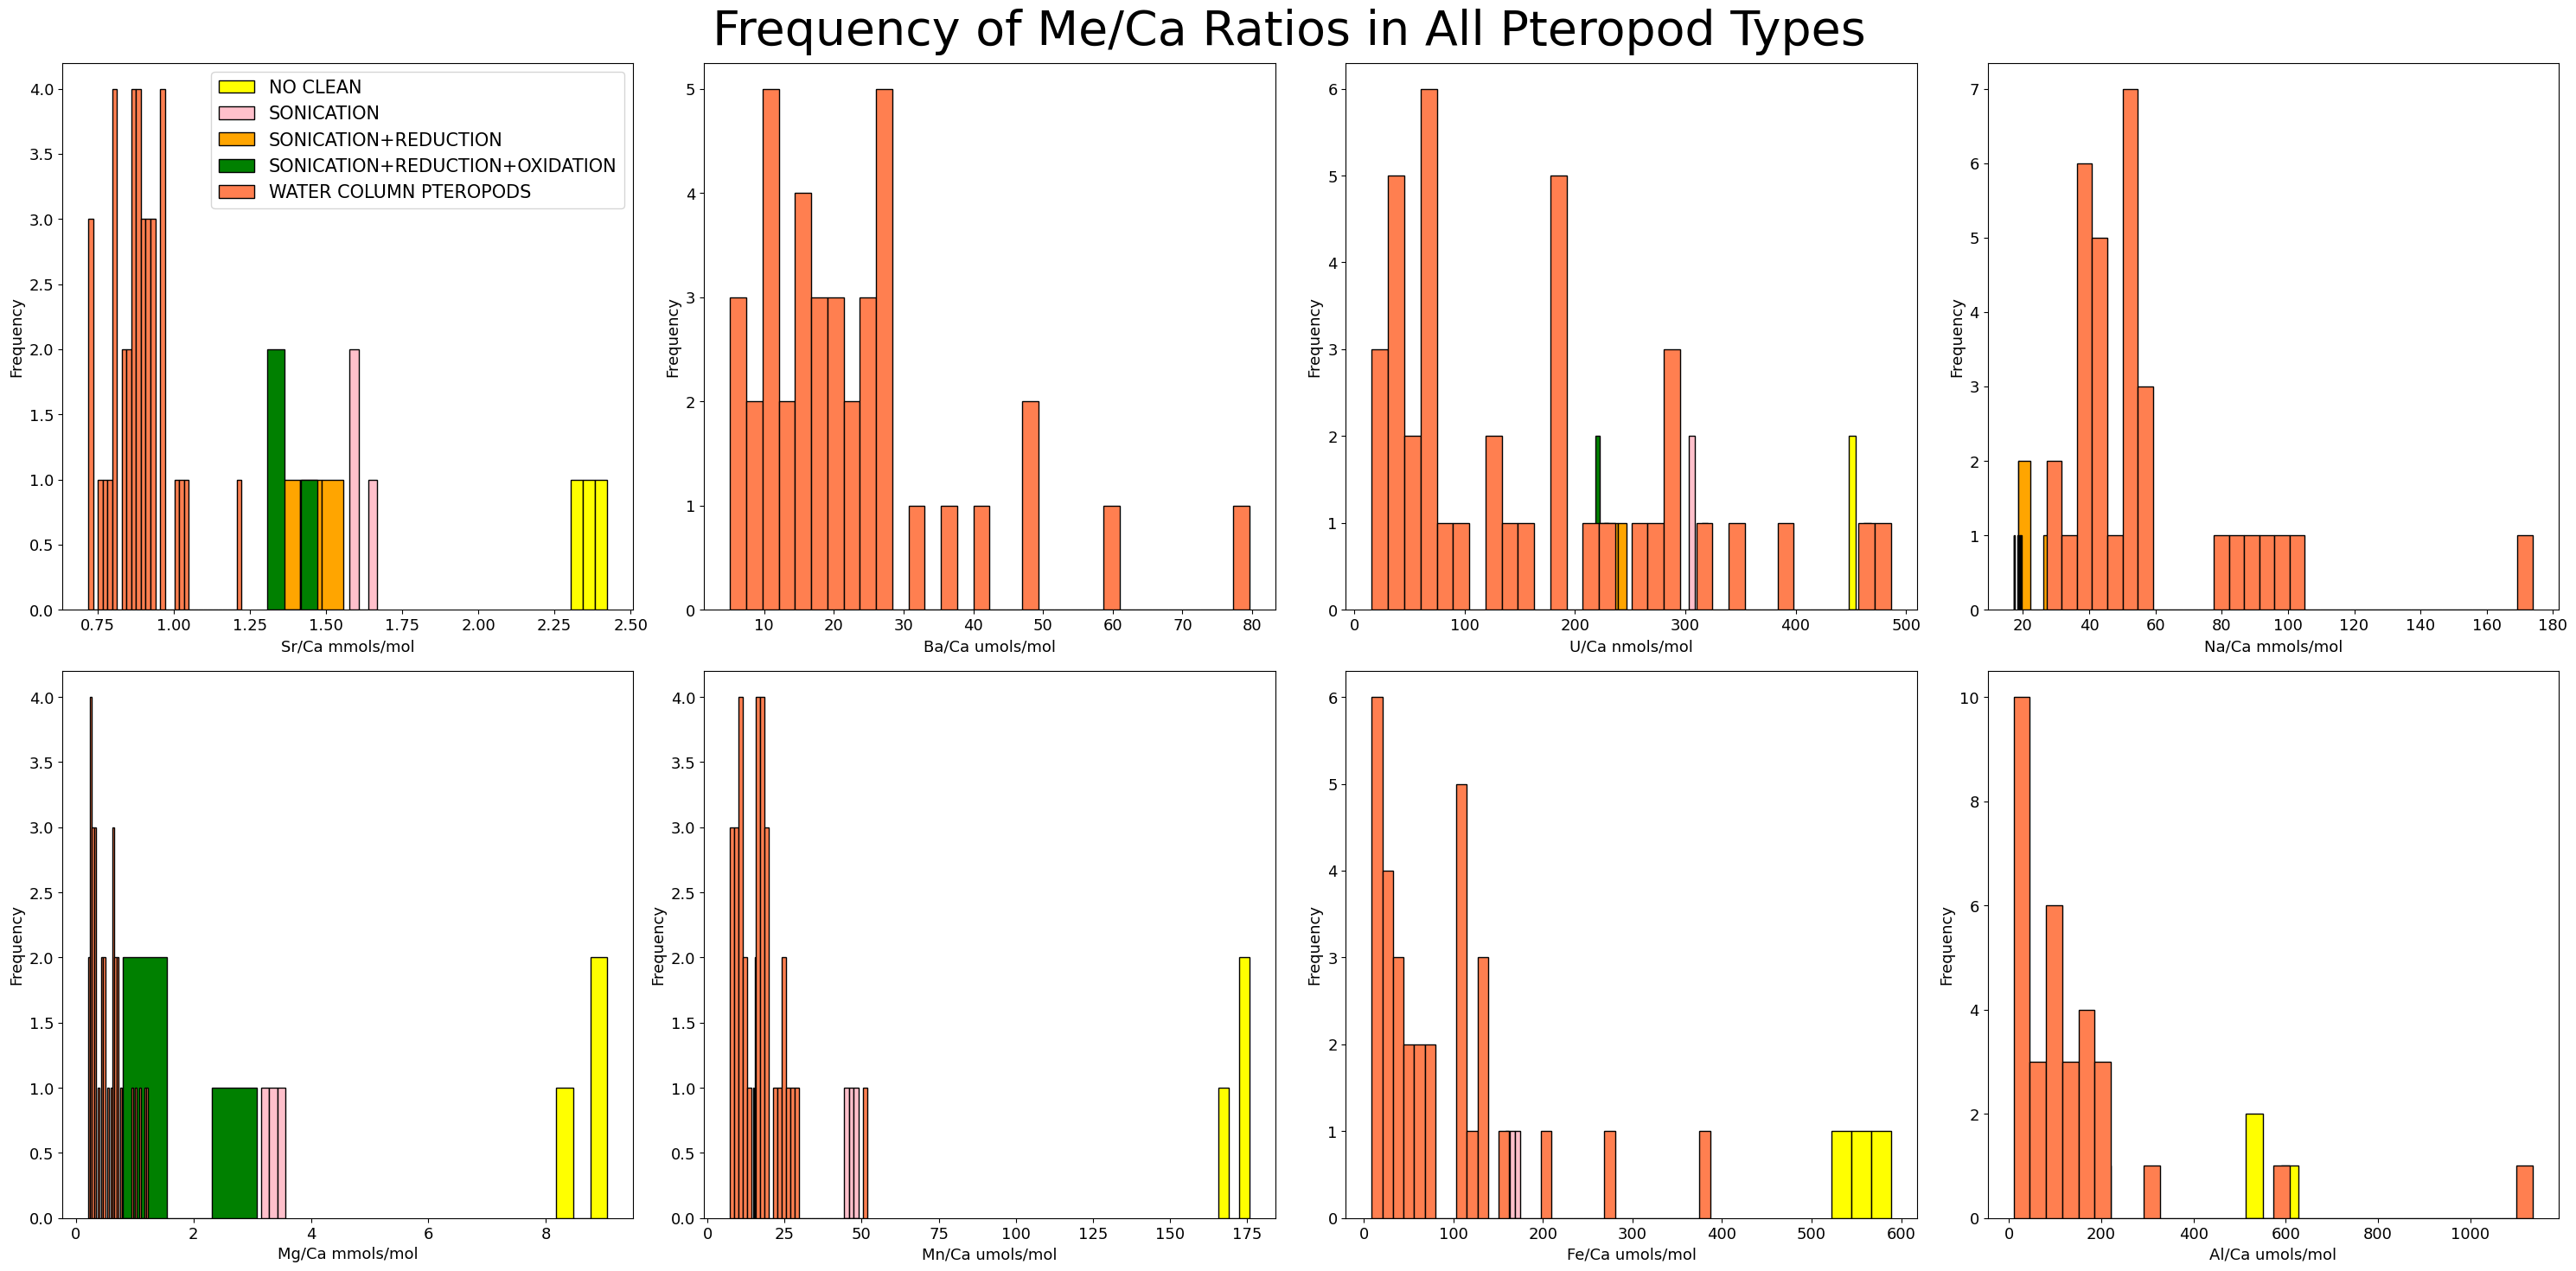

In [20]:
# graph 13: Creating subplots with multiple histograms for Me/Ca for all pteropod types
fig, (axes) = plt.subplots(nrows=2, ncols=4, figsize=(30, 15))

      
#Sr/Ca
axes[0,0].hist(nocleanSr, bins=3, color='Yellow', edgecolor='black')

axes[0,0].hist(sonicSr, bins=3, color='Pink', edgecolor='black')

axes[0,0].hist(redsonicSr, bins=3, color='orange', edgecolor='black')

axes[0,0].hist(oxredsonicSr, bins=3, color='green', edgecolor='black')

axes[0,0].hist(waterpteroSr, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,0].set_xlabel('Sr/Ca mmols/mol')
axes[0,0].set_ylabel('Frequency')

#Ba/Ca
axes[0,1].hist(nocleanBa, bins=3, color='Yellow', edgecolor='black')

axes[0,1].hist(sonicBa, bins=3, color='Pink', edgecolor='black')

axes[0,1].hist(redsonicBa, bins=3, color='orange', edgecolor='black')

axes[0,1].hist(oxredsonicBa, bins=3, color='green', edgecolor='black')

axes[0,1].hist(waterpteroBa, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,1].set_xlabel('Ba/Ca umols/mol')
axes[0,1].set_ylabel('Frequency')


#U/Ca
axes[0,2].hist(nocleanU, bins=3, color='Yellow', edgecolor='black')

axes[0,2].hist(sonicU, bins=3, color='Pink', edgecolor='black')

axes[0,2].hist(redsonicU, bins=3, color='orange', edgecolor='black')

axes[0,2].hist(oxredsonicU, bins=3, color='green', edgecolor='black')

axes[0,2].hist(waterpteroU, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,2].set_xlabel('U/Ca nmols/mol')
axes[0,2].set_ylabel('Frequency')

#Na/Ca
axes[0,3].hist(nocleanNa, bins=3, color='Yellow', edgecolor='black')

axes[0,3].hist(sonicNa, bins=3, color='Pink', edgecolor='black')

axes[0,3].hist(redsonicNa, bins=3, color='orange', edgecolor='black')

axes[0,3].hist(oxredsonicNa, bins=3, color='green', edgecolor='black')

axes[0,3].hist(waterpteroNa, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,3].set_xlabel('Na/Ca mmols/mol')
axes[0,3].set_ylabel('Frequency')

#Mg/Ca

axes[1,0].hist(nocleanMg, bins=3, color='Yellow', edgecolor='black')

axes[1,0].hist(sonicMg, bins=3, color='Pink', edgecolor='black')

axes[1,0].hist(redsonicMg, bins=3, color='orange', edgecolor='black')

axes[1,0].hist(oxredsonicMg, bins=3, color='green', edgecolor='black')

axes[1,0].hist(waterpteroMg, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,0].set_xlabel('Mg/Ca mmols/mol')
axes[1,0].set_ylabel('Frequency')

#Mn/Ca

axes[1,1].hist(nocleanMn, bins=3, color='Yellow', edgecolor='black')

axes[1,1].hist(sonicMn, bins=3, color='Pink', edgecolor='black')

axes[1,1].hist(redsonicMn, bins=3, color='orange', edgecolor='black')

axes[1,1].hist(oxredsonicMn, bins=3, color='green', edgecolor='black')

axes[1,1].hist(waterpteroMn, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,1].set_xlabel('Mn/Ca umols/mol')
axes[1,1].set_ylabel('Frequency')

#Fe/Ca

axes[1,2].hist(nocleanFe, bins=3, color='Yellow', edgecolor='black')

axes[1,2].hist(sonicFe, bins=3, color='Pink', edgecolor='black')

axes[1,2].hist(redsonicFe, bins=3, color='orange', edgecolor='black')

axes[1,2].hist(oxredsonicFe, bins=3, color='green', edgecolor='black')

axes[1,2].hist(waterpteroFe, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,2].set_xlabel('Fe/Ca umols/mol')
axes[1,2].set_ylabel('Frequency')

#Al/Ca

axes[1,3].hist(nocleanAl, bins=3, color='Yellow', edgecolor='black')

axes[1,3].hist(sonicAl, bins=3, color='Pink', edgecolor='black')

axes[1,3].hist(redsonicAl, bins=3, color='orange', edgecolor='black')

axes[1,3].hist(oxredsonicAl, bins=3, color='green', edgecolor='black')

axes[1,3].hist(waterpteroAl, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,3].set_xlabel('Al/Ca umols/mol')
axes[1,3].set_ylabel('Frequency')

fig.suptitle('Frequency of Me/Ca Ratios in All Pteropod Types', fontsize = 40)

# Adjusting layout for better spacing
fig.tight_layout()


#legend
tech = 'NO CLEAN', 'SONICATION', 'SONICATION+REDUCTION', 'SONICATION+REDUCTION+OXIDATION', 'WATER COLUMN PTEROPODS'
axes[0,0].legend(tech, fontsize = 15)

# Display the figure
plt.show()

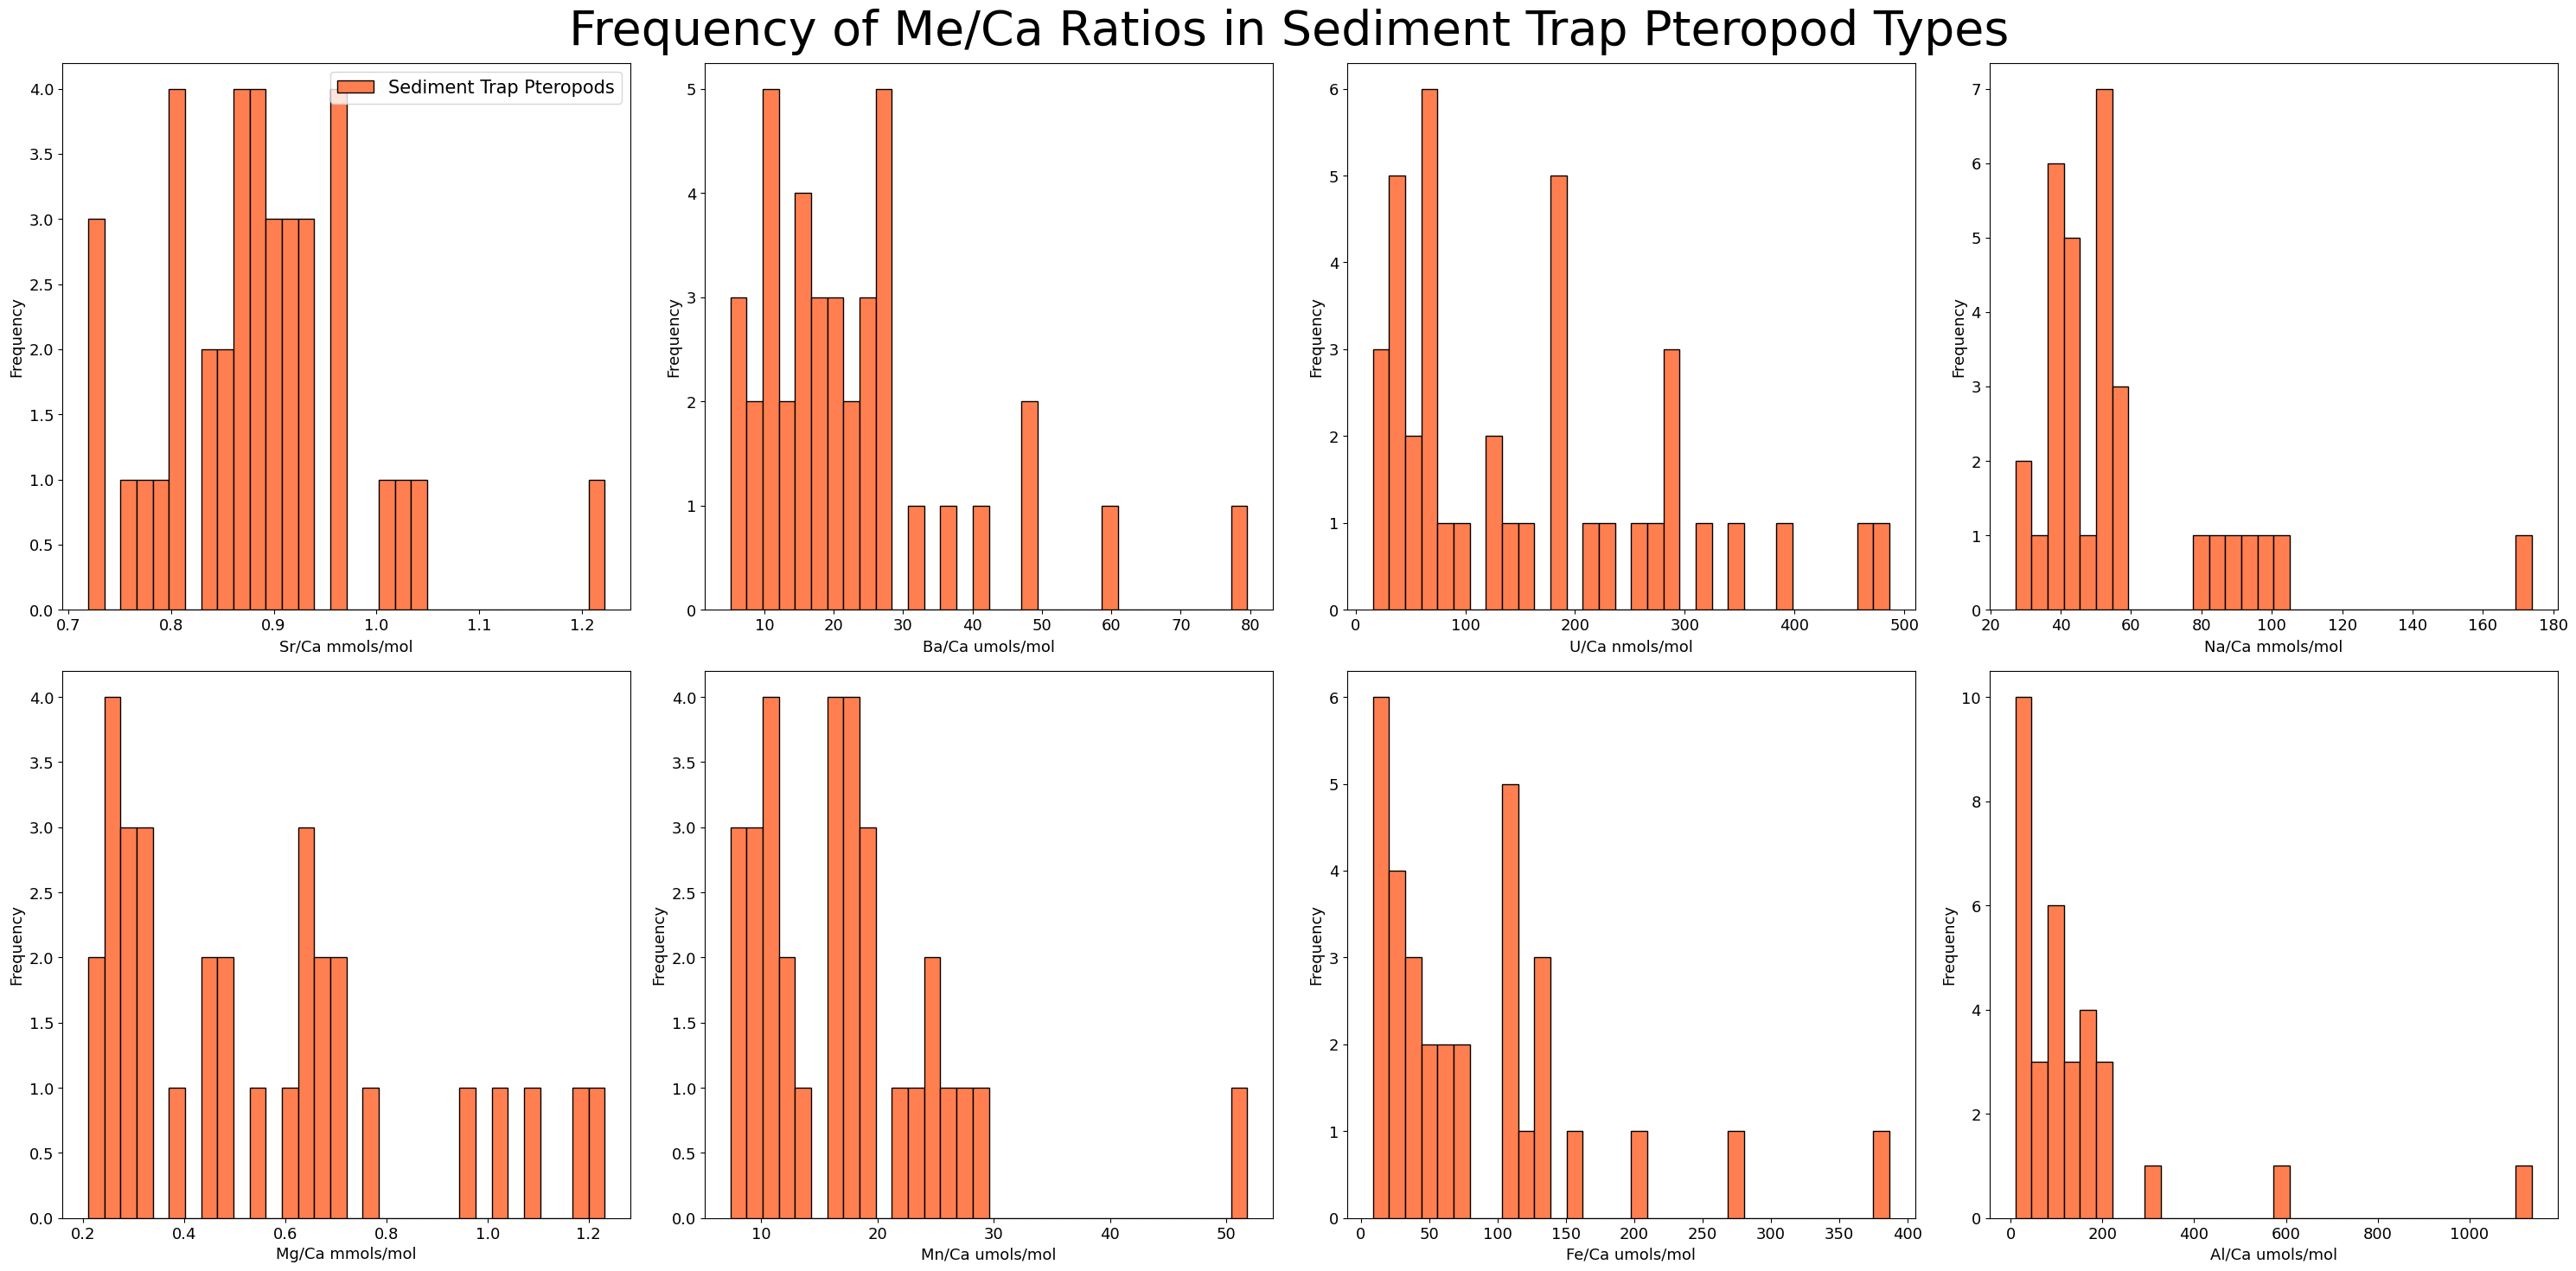

In [21]:
# graph 13: Creating subplots with multiple histograms for Me/Ca for water column pteropods
fig, (axes) = plt.subplots(nrows=2, ncols=4, figsize=(30, 15))

      
#Sr/Ca
axes[0,0].hist(waterpteroSr, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,0].set_xlabel('Sr/Ca mmols/mol')
axes[0,0].set_ylabel('Frequency')

#Ba/Ca

axes[0,1].hist(waterpteroBa, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,1].set_xlabel('Ba/Ca umols/mol')
axes[0,1].set_ylabel('Frequency')


#U/Ca

axes[0,2].hist(waterpteroU, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,2].set_xlabel('U/Ca nmols/mol')
axes[0,2].set_ylabel('Frequency')

#Na/Ca

axes[0,3].hist(waterpteroNa, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[0,3].set_xlabel('Na/Ca mmols/mol')
axes[0,3].set_ylabel('Frequency')

#Mg/Ca

axes[1,0].hist(waterpteroMg, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,0].set_xlabel('Mg/Ca mmols/mol')
axes[1,0].set_ylabel('Frequency')

#Mn/Ca

axes[1,1].hist(waterpteroMn, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,1].set_xlabel('Mn/Ca umols/mol')
axes[1,1].set_ylabel('Frequency')

#Fe/Ca


axes[1,2].hist(waterpteroFe, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,2].set_xlabel('Fe/Ca umols/mol')
axes[1,2].set_ylabel('Frequency')

#Al/Ca


axes[1,3].hist(waterpteroAl, bins=32, color='coral', edgecolor='black')

# Adding labels and title
axes[1,3].set_xlabel('Al/Ca umols/mol')
axes[1,3].set_ylabel('Frequency')

fig.suptitle('Frequency of Me/Ca Ratios in Sediment Trap Pteropod Types', fontsize = 40)

# Adjusting layout for better spacing
fig.tight_layout()


#legend
tech = 'Sediment Trap Pteropods', 
axes[0,0].legend(tech, fontsize = 15)

# Display the figure
plt.show()

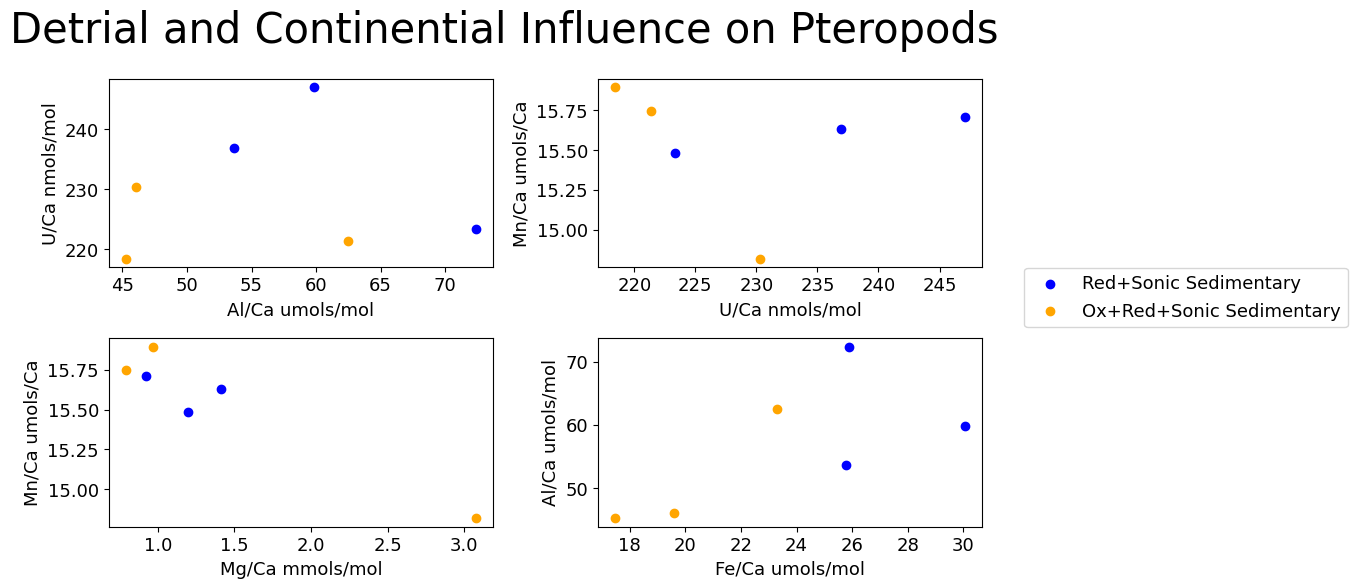

In [22]:
#graph 14: create subplots w linear regression lines for U/Ca vs Mg/Ca , Al/Ca vs U/Ca, U/Ca vs Mn/Ca, Mg/Ca vs Mn/Ca, Fe/Ca vs Al/ca
fig, (axes) = plt.subplots(nrows=2, ncols=2, figsize=(10,6))


# axes[0,0].scatter(waterpteroAl, waterpteroU, color = 'green')
axes[0,0].scatter(redsonicAl, redsonicU, color = 'blue')
axes[0,0].scatter(oxredsonicAl, oxredsonicU, color ='orange')
axes[0,0].set_xlabel('Al/Ca umols/mol')
axes[0,0].set_ylabel('U/Ca nmols/mol')

# axes[0,1].scatter(waterpteroU, waterpteroMn, color = 'green')
axes[0,1].scatter(redsonicU, redsonicMn, color = 'blue')
axes[0,1].scatter(oxredsonicU, oxredsonicMn, color ='orange')
axes[0,1].set_xlabel('U/Ca nmols/mol')
axes[0,1].set_ylabel('Mn/Ca umols/Ca')

# axes[1,0].scatter(waterpteroMg, waterpteroMn, color = 'green')
axes[1,0].scatter(redsonicMg, redsonicMn, color = 'blue')
axes[1,0].scatter(oxredsonicMg, oxredsonicMn, color ='orange')
axes[1,0].set_xlabel('Mg/Ca mmols/mol')
axes[1,0].set_ylabel('Mn/Ca umols/Ca')

# axes[1,1].scatter(waterpteroFe, waterpteroAl, color = 'green')
axes[1,1].scatter(redsonicFe, redsonicAl, color = 'blue')
axes[1,1].scatter(oxredsonicFe, oxredsonicAl, color ='orange')
axes[1,1].set_xlabel('Fe/Ca umols/mol')
axes[1,1].set_ylabel('Al/Ca umols/mol')

fig.suptitle('Detrial and Continential Influence on Pteropods', fontsize = 30)

label = 'Red+Sonic Sedimentary', 'Ox+Red+Sonic Sedimentary'
fig.legend(label, bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

# Adjusting layout for better spacing
fig.tight_layout()


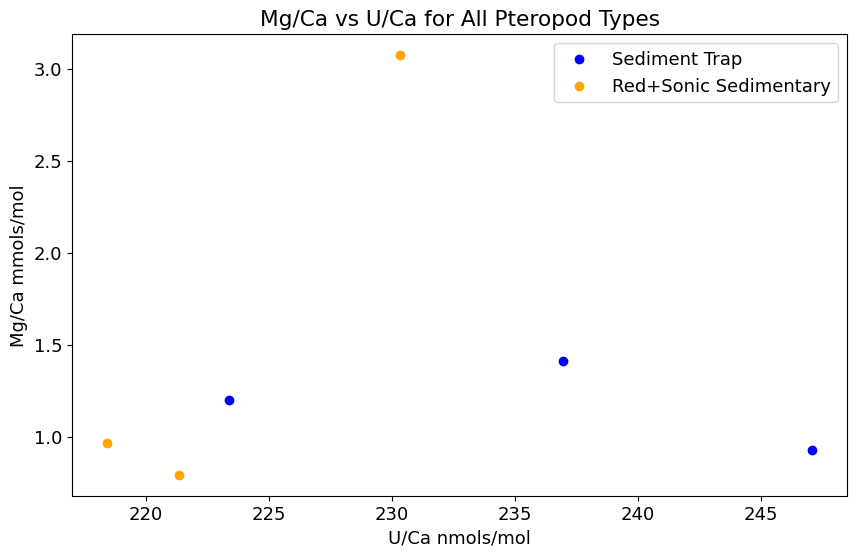

In [23]:
#U/Ca vs Mg/C
plt.figure(figsize=(10, 6))



# plt.scatter(waterpteroU, waterpteroMg, color = 'green')
plt.scatter(redsonicU, redsonicMg, color = 'blue')
plt.scatter(oxredsonicU, oxredsonicMg, color = 'orange')


plt.xlabel('U/Ca nmols/mol')
plt.ylabel('Mg/Ca mmols/mol')
plt.title ('Mg/Ca vs U/Ca for All Pteropod Types')
label = 'Sediment Trap', 'Red+Sonic Sedimentary', 'Ox+Red+Sonic Sedimentary'
plt.legend(label, loc='upper right')

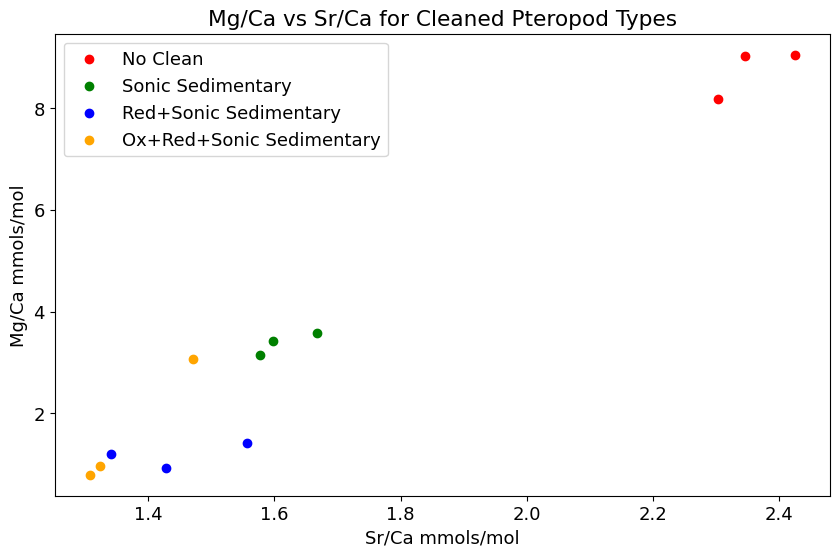

In [24]:
#U/Ca vs Sr/Ca
plt.figure(figsize=(10, 6))


plt.scatter(nocleanSr, nocleanMg, color = 'r')
plt.scatter(sonicSr, sonicMg, color = 'green')
plt.scatter(redsonicSr, redsonicMg, color = 'blue')
plt.scatter(oxredsonicSr, oxredsonicMg, color = 'orange')


plt.xlabel('Sr/Ca mmols/mol')
plt.ylabel('Mg/Ca mmols/mol')
plt.title ('Mg/Ca vs Sr/Ca for Cleaned Pteropod Types')
label = 'No Clean','Sonic Sedimentary', 'Red+Sonic Sedimentary', 'Ox+Red+Sonic Sedimentary'
plt.legend(label, loc='upper left')

23.058978811506794
6.010460078426109
3.836474830649734


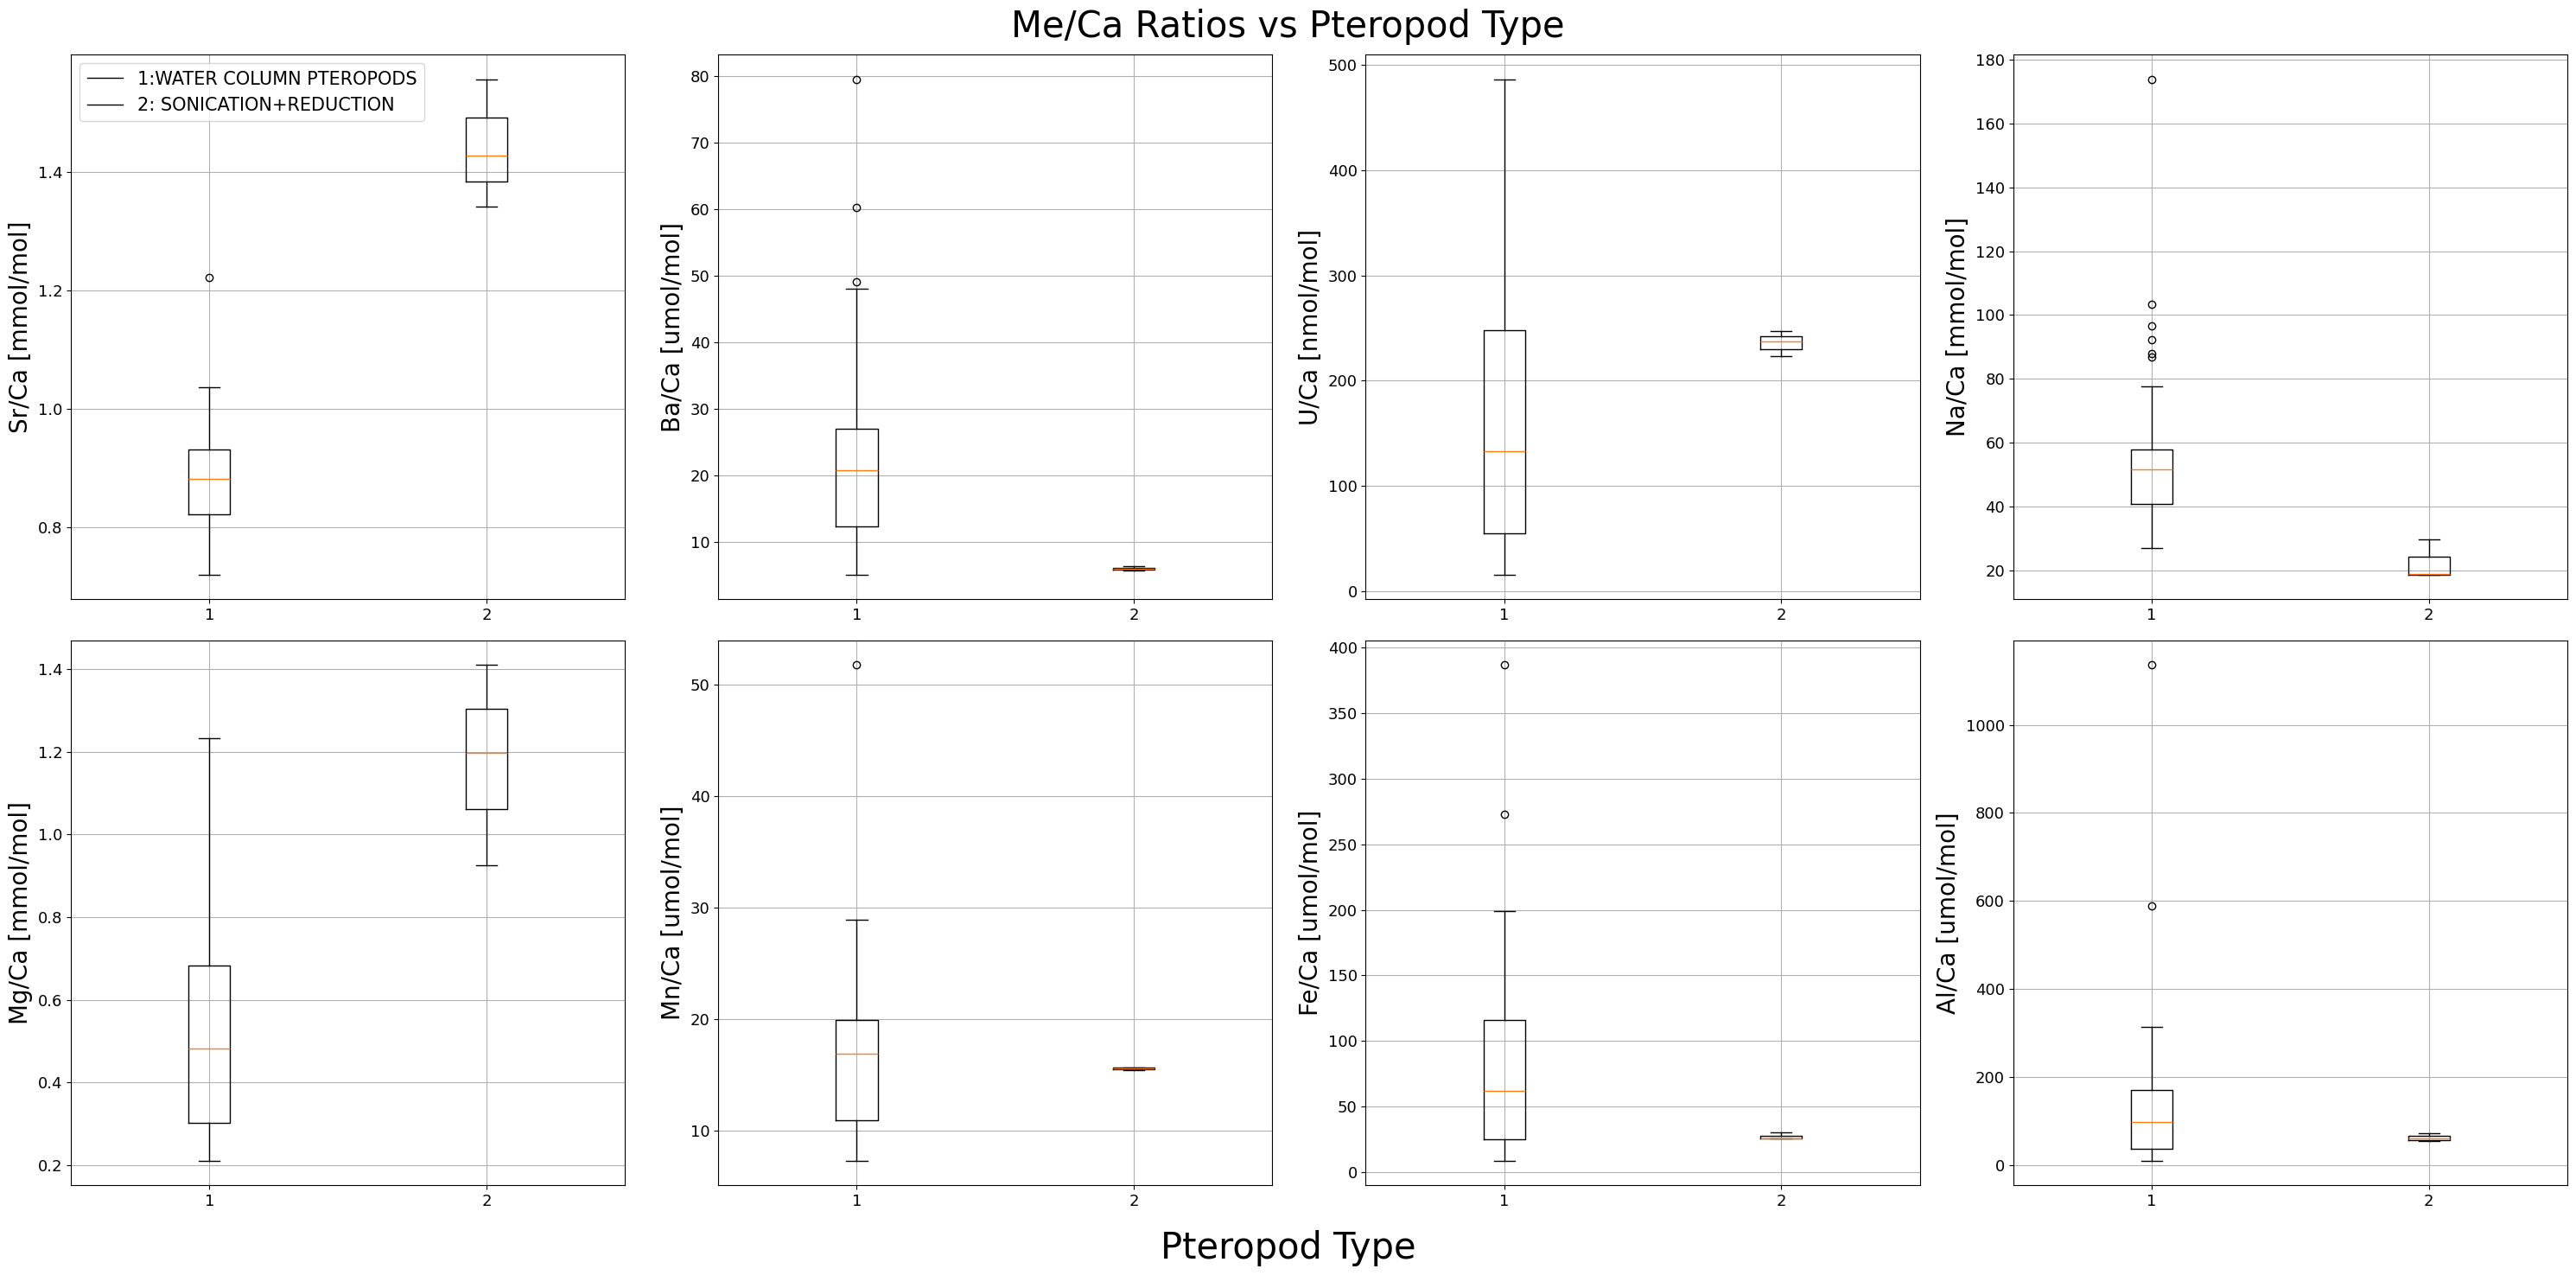

In [25]:
#Graph 9: combined Me/Ca ratios vs different cleaning types sedimentary pterods and water column pteropods 

#create variables 
SWSr = waterpteroSr, redsonicSr
SWBa = waterpteroBa, redsonicBa
SWU = waterpteroU, redsonicU
SWNa = waterpteroNa, redsonicNa
SWMg = waterpteroMg, redsonicMg
SWMn = waterpteroMn, redsonicMn
SWFe = waterpteroFe, redsonicFe
SWAl = waterpteroAl, redsonicAl

#create figure
fig, axes = plt.subplots(2, 4, figsize=(30, 15), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()


ax1.boxplot(SWSr)

ax2.boxplot(SWBa)

ax3.boxplot(SWU)

ax4.boxplot(SWNa)

ax5.boxplot(SWMg)

ax6.boxplot(SWMn)

ax7.boxplot(SWFe) 

ax8.boxplot(SWAl)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios vs Pteropod Type', fontsize = 30)
fig.supxlabel('Pteropod Type', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)
lab = '1:WATER COLUMN PTEROPODS','2: SONICATION+REDUCTION'
#set legend
ax1.legend(lab, fontsize = 15)

#fixing spacing layout
fig.tight_layout()

#add grid lines
ax1.grid()
ax2.grid()
ax3.grid()
ax4.grid()
ax5.grid()
ax6.grid()
ax7.grid()
ax8.grid()



avgBaw = sum(waterpteroBa)/len(waterpteroBa)

avgBas = sum(redsonicBa)/len(redsonicBa)

ratioBa = avgBaw/avgBas

print(avgBaw)
print(avgBas)
print(ratioBa)


In [26]:
srwavg = sum(waterpteroSr)/len(waterpteroSr)

srsavg = sum(redsonicSr)/len(redsonicSr)

print(srwavg/srsavg)

0.6135710517729791


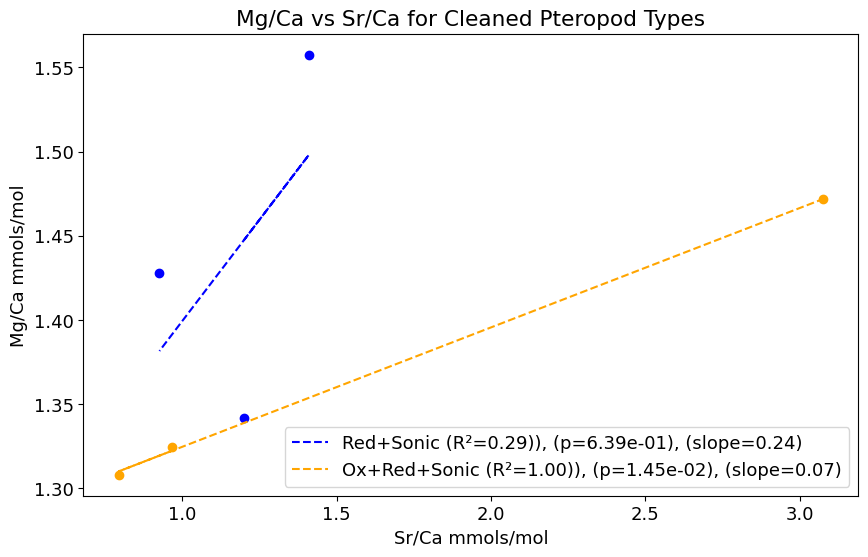

In [27]:
#U/Ca vs Sr/Ca
plt.figure(figsize=(10, 6))

plt.scatter(redsonicMg, redsonicSr, color = 'blue')
plt.scatter(oxredsonicMg, oxredsonicSr, color = 'orange')

# calulate linear regression
slopeSrMg, interceptSrMg, r_valueSrMg, p_valueSrMg, std_errSrMg = linregress(redsonicMg, redsonicSr)
regression_ySrMg = slopeSrMg * redsonicMg + interceptSrMg
r_squaredSrMg = r_valueSrMg**2

#plot linear regression
plt.plot(redsonicMg, regression_ySrMg, label=f'Red+Sonic (R²={r_squaredSrMg:.2f})), (p={p_valueSrMg:.2e}), (slope={slopeSrMg:.2f})', color='b', linestyle='--')

# calulate linear regression
slopeSrMg, interceptSrMg, r_valueSrMg, p_valueSrMg, std_errSrMg = linregress(oxredsonicMg, oxredsonicSr)
regression_ySrMg = slopeSrMg * oxredsonicMg + interceptSrMg
r_squaredSrMg = r_valueSrMg**2

#plot linear regression
plt.plot(oxredsonicMg, regression_ySrMg, label=f'Ox+Red+Sonic (R²={r_squaredSrMg:.2f})), (p={p_valueSrMg:.2e}), (slope={slopeSrMg:.2f})', color='orange', linestyle='--')


plt.xlabel('Sr/Ca mmols/mol')
plt.ylabel('Mg/Ca mmols/mol')
plt.title ('Mg/Ca vs Sr/Ca for Cleaned Pteropod Types')
label = 'Red+Sonic Sedimentary', 'Ox+Red+Sonic Sedimentary'
plt.legend(loc='lower right')

Index(['Type', 'ID', 'Label', 'Batch', 'Sr/Ca [mmol/mol]', 'Ba/Ca [umol/mol]',
       'U/Ca [nmol/mol]', 'Na_Ca [mmol/mol]', 'Mg_Ca [mmol/mol]',
       'Mn_Ca [umol/mol]', 'Fe_Ca [umol/mol]', 'Al_Ca [umol/mol]',
       'Number of shells', 'LDX', 'cup'],
      dtype='object')


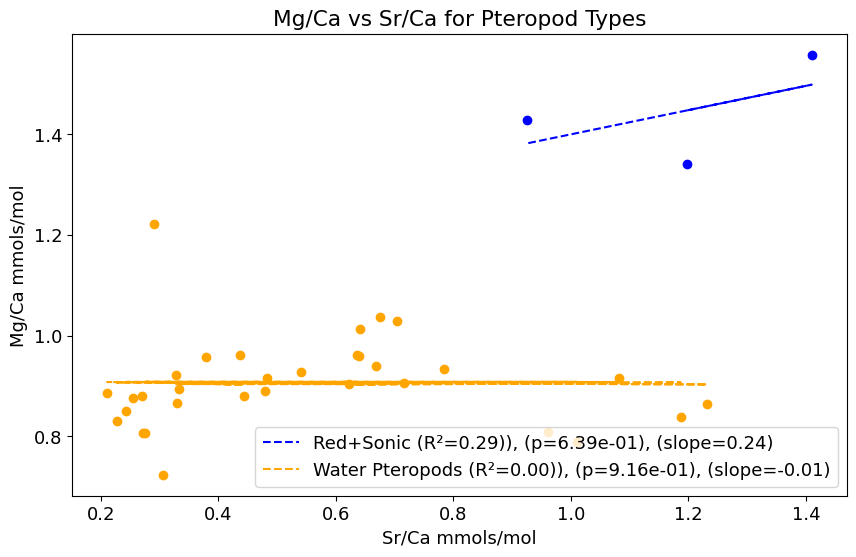

In [28]:
#U/Ca vs Sr/Ca
plt.figure(figsize=(10, 6))

print(wdata.columns)
wMg = wdata['Mg_Ca [mmol/mol]']
wSr = wdata['Sr/Ca [mmol/mol]']

plt.scatter(redsonicMg, redsonicSr, color = 'blue')
plt.scatter(wMg, wSr, color = 'orange')

# calulate linear regression
slopeSrMg, interceptSrMg, r_valueSrMg, p_valueSrMg, std_errSrMg = linregress(redsonicMg, redsonicSr)
regression_ySrMg = slopeSrMg * redsonicMg + interceptSrMg
r_squaredSrMg = r_valueSrMg**2

#plot linear regression
plt.plot(redsonicMg, regression_ySrMg, label=f'Red+Sonic (R²={r_squaredSrMg:.2f})), (p={p_valueSrMg:.2e}), (slope={slopeSrMg:.2f})', color='b', linestyle='--')

# calulate linear regression
slopeSrMg, interceptSrMg, r_valueSrMg, p_valueSrMg, std_errSrMg = linregress(wMg, wSr)
regression_ySrMg = slopeSrMg * wMg + interceptSrMg
r_squaredSrMg = r_valueSrMg**2

#plot linear regression
plt.plot(waterpteroMg, regression_ySrMg, label=f'Water Pteropods (R²={r_squaredSrMg:.2f})), (p={p_valueSrMg:.2e}), (slope={slopeSrMg:.2f})', color='orange', linestyle='--')


plt.xlabel('Sr/Ca mmols/mol')
plt.ylabel('Mg/Ca mmols/mol')
plt.title ('Mg/Ca vs Sr/Ca for Pteropod Types')
label = 'Red+Sonic Sedimentary', 'Water Column'
plt.legend(loc='lower right')

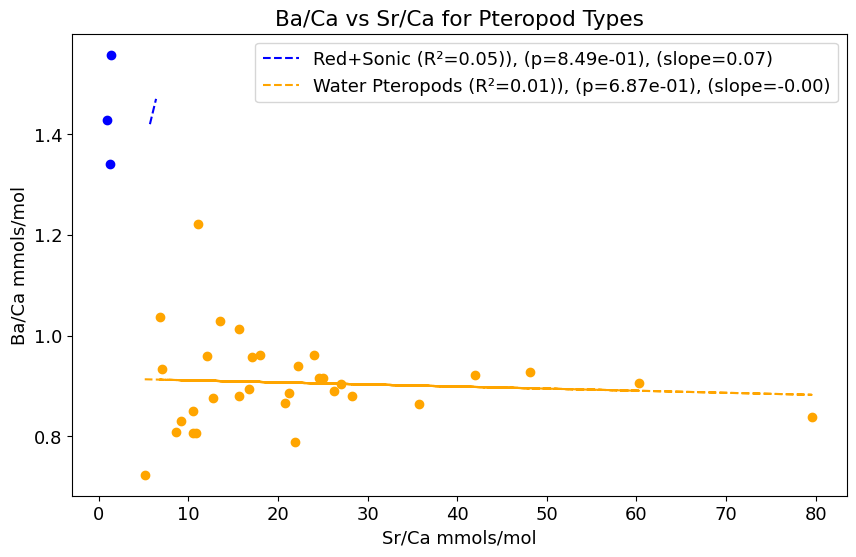

In [29]:
#U/Ca vs Sr/Ca
plt.figure(figsize=(10, 6))


wBa = wdata['Ba/Ca [umol/mol]']
wSr = wdata['Sr/Ca [mmol/mol]']

plt.scatter(redsonicMg, redsonicSr, color = 'blue')
plt.scatter(wBa, wSr, color = 'orange')

# calulate linear regression
slopeSrBa, interceptSrBa, r_valueSrBa, p_valueSrBa, std_errSrBa = linregress(redsonicBa, redsonicSr)
regression_ySrBa = slopeSrBa * redsonicBa + interceptSrBa
r_squaredSrBa = r_valueSrBa**2

#plot linear regression
plt.plot(redsonicBa, regression_ySrBa, label=f'Red+Sonic (R²={r_squaredSrBa:.2f})), (p={p_valueSrBa:.2e}), (slope={slopeSrBa:.2f})', color='b', linestyle='--')

# calulate linear regression
slopeWSrBa, interceptWSrBa, r_valueWSrBa, p_valueWSrBa, std_errWSrBa = linregress(wBa, wSr)
regression_yWSrBa = slopeWSrBa * wBa + interceptWSrBa
r_squaredWSrBa = r_valueWSrBa**2

#plot linear regression
plt.plot(wBa, regression_yWSrBa, label=f'Water Pteropods (R²={r_squaredWSrBa:.2f})), (p={p_valueWSrBa:.2e}), (slope={slopeWSrBa:.2f})', color='orange', linestyle='--')


plt.xlabel('Sr/Ca mmols/mol')
plt.ylabel('Ba/Ca mmols/mol')
plt.title ('Ba/Ca vs Sr/Ca for Pteropod Types')
label = 'Red+Sonic Sedimentary', 'Water Column'
plt.legend(loc='upper right')